# A Business Intelligence Approach for Electricity Demand Forecasting and Energy Consumption Pattern Analysis

# Authors

Maisam Mahmoud Almashaikh

202320121

**Supervised by:**

Dr. Wasef Matar

**Course:** 307498 – Graduation Project

**Semester:** Summer Semester, 2026/2027

# Contents

1. Abstract

2. Acknowledgment

3. Business Intelligence Project Description and Objectives

4. Data Research and Acquiring Effort

5. Links to Raw Data

6. Data Description and Understanding

7. Data Primary Cleaning and Transformation

8. Data Visualization and Insights

9. Advanced Analytics and AI Modeling

10. Tools Research and Selection Effort

11. Project Deployment Effort – Use Case

12. Results

13. References

# Abstract

This project analyzes hourly electricity demand and energy generation using data on electricity consumption, generation sources, electricity prices, and weather conditions. The main goal is to understand the patterns in electricity demand, identify different demand conditions, and develop a model that can accurately predict electricity demand.

The analysis combined descriptive and exploratory statistics, correlation analysis, time-series analysis, K-Means clustering, and machine learning. Four electricity-demand clusters were identified, representing different demand conditions from low to high demand. Two prediction models, Ridge Regression and XGBoost, were also evaluated. XGBoost achieved the best performance on the test set, with an MAE of 397.26 MW, RMSE of 560.96 MW, MAPE of 1.42%, and R² of 0.9850. The feature-importance results showed that recent electricity demand and time-related variables were the most important predictors.

The final results were integrated into Tableau dashboards to provide an interactive view of electricity demand, demand clusters, and energy-generation sources. Overall, the project combines statistical analysis, clustering, predictive modeling, and Business Intelligence to provide a clearer understanding of electricity-demand patterns and energy-system behavior.

# Acknowledgment

I would like to express my sincere appreciation to my supervisor and instructors for their guidance, valuable insights, and continuous support throughout the completion of this project. Their knowledge, feedback, and encouragement contributed significantly to the successful development of this work and enriched my understanding of Business Intelligence, Data Analytics, and Artificial Intelligence applications.

I am also deeply grateful to my family for their unwavering support, patience, and motivation throughout my academic journey. Their encouragement provided me with the determination and confidence needed to overcome challenges and achieve my goals.

I would also like to thank my friends and colleagues for their support, cooperation, and positive encouragement throughout the project. Their assistance and shared experiences made this journey both productive and enjoyable.

In addition, I would like to acknowledge the faculty and staff members whose dedication to education and academic excellence provided a supportive learning environment that encouraged growth, innovation, and critical thinking.

Finally, I extend my gratitude to everyone who contributed, directly or indirectly, to the completion of this project. Their support and encouragement have played an important role in my academic development and personal growth.

# Business Intelligence Project Description and Objectives

## Project Description and Goal

This project aims to analyze electricity demand and energy generation patterns using Business Intelligence, statistical analysis, clustering, and machine learning techniques. The analysis is based on hourly electricity demand, electricity generation, electricity prices, and weather data, with the goal of understanding electricity demand behavior, identifying different demand conditions, and supporting data-driven energy analysis.

The study uses several analytical approaches, including descriptive and exploratory data analysis, correlation analysis, time-series analysis, K-Means clustering, and predictive modeling. Python and Google Colab were used for data preprocessing, statistical analysis, feature engineering, clustering, and machine learning, while Tableau was used to develop interactive dashboards and Business Intelligence visualizations.

The project evaluates electricity demand patterns and identifies four distinct demand clusters representing different electricity-demand conditions. Two machine learning models, Ridge Regression and XGBoost, were developed and evaluated to predict actual electricity demand. The project also analyzes the importance of different demand, temporal, and energy-generation variables and examines the behavior of different energy sources over time.

The final outcome is a Business Intelligence decision-support solution that integrates statistical analysis, clustering, predictive analytics, and interactive Tableau dashboards to provide a clearer understanding of electricity demand patterns, demand conditions, and energy-generation behavior.

## Project Objectives

o Analyze hourly electricity demand and energy-generation patterns.

o Perform exploratory and descriptive analysis to understand the main characteristics and relationships within the data.

o Examine temporal patterns and the relationship between electricity demand and historical demand observations.

o Analyze the relationships between electricity demand, energy generation, electricity prices, and weather variables.

o Apply K-Means clustering to identify distinct electricity-demand conditions.

o Compare the characteristics of the identified demand clusters and their associated energy-generation patterns.

o Develop Ridge Regression and XGBoost models to predict actual electricity demand.

o Evaluate and compare model performance using MAE, RMSE, MAPE, and R².

o Identify the most important features contributing to electricity-demand prediction.

o Analyze trends and differences among the available energy-generation sources.

o Develop interactive Tableau dashboards to visualize electricity demand, demand clusters, and energy-generation patterns.

o Provide a Business Intelligence decision-support solution for exploring electricity-demand and energy-generation behavior.

# Data Research and Acquiring Effort

The data used in this project were obtained from the publicly available Hourly Energy Demand Generation and Weather dataset on Kaggle. The dataset contains hourly electricity consumption, electricity generation, electricity prices, and weather information for Spain.

The electricity consumption and generation data were originally retrieved from the ENTSO-E Transparency Platform, which provides data from Transmission System Operators (TSOs). The electricity settlement price data were obtained from the Spanish Transmission System Operator, Red Eléctrica Española (REE). The weather data were collected through the OpenWeather API for five of the largest cities in Spain and were subsequently made publicly available through the Kaggle dataset.

For this project, the downloaded files were provided as two datasets: energy_dataset.csv and weather_features.csv. The Energy Dataset contains 35,064 hourly observations and 29 variables, while the Weather Dataset contains 178,396 observations and 17 variables. The two datasets were examined separately and then integrated using their common hourly timestamps. This integrated dataset forms the basis for the subsequent data cleaning, feature engineering,  electricity demand forecasting, and clustering stages.

# Links to Raw Data

The raw datasets used in this project were obtained from the publicly available Kaggle dataset

"**Hourly Energy Demand Generation and Weather**" (Jhana, n.d.).

Direct access: https://www.kaggle.com/datasets/nicholasjhana/energy-consumption-generation-prices-and-weather

The downloaded dataset contains the two raw files used in this project:

- energy_dataset.csv
- weather_features.csv

# Data Description and Understandings

## Import Libraries

The following libraries are used to load, examine, and analyze the electricity and weather datasets.

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings

warnings.filterwarnings("ignore")

pd.set_option("display.max_columns", None)

## Upload and Load Datasets

Uploades and loades the datasets into Pandas DataFrames to examine their structure and contents.

In [ ]:
from google.colab import files
import io

uploaded = files.upload()

files_list = list(uploaded.keys())

energy_file = [file for file in files_list if "energy" in file.lower()][0]
weather_file = [file for file in files_list if "weather" in file.lower()][0]

energy = pd.read_csv(io.BytesIO(uploaded[energy_file]))
weather = pd.read_csv(io.BytesIO(uploaded[weather_file]))

Saving Weather features.csv to Weather features.csv
Saving Energy Dataset.csv to Energy Dataset.csv


## Energy Dataset Preview

Displays the first five records of the Energy Dataset to provide an initial view of the electricity-related variables.

energy.head()

##

In [ ]:
energy.head()

,time,generation biomass,generation fossil brown coal/lignite,generation fossil coal-derived gas,generation fossil gas,generation fossil hard coal,generation fossil oil,generation fossil oil shale,generation fossil peat,generation geothermal,generation hydro pumped storage aggregated,generation hydro pumped storage consumption,generation hydro run-of-river and poundage,generation hydro water reservoir,generation marine,generation nuclear,generation other,generation other renewable,generation solar,generation waste,generation wind offshore,generation wind onshore,forecast solar day ahead,forecast wind offshore eday ahead,forecast wind onshore day ahead,total load forecast,total load actual,price day ahead,price actual
0,2015-01-01 00:00:00+01:00,447.0,329.0,0.0,4844.0,4821.0,162.0,0.0,0.0,0.0,NaN,863.0,1051.0,1899.0,0.0,7096.0,43.0,73.0,49.0,196.0,0.0,6378.0,17,NaN,6436,26118,25385.0,50.10,65.41
1,2015-01-01 01:00:00+01:00,449.0,328.0,0.0,5196.0,4755.0,158.0,0.0,0.0,0.0,NaN,920.0,1009.0,1658.0,0.0,7096.0,43.0,71.0,50.0,195.0,0.0,5890.0,16,NaN,5856,24934,24382.0,48.10,64.92
2,2015-01-01 02:00:00+01:00,448.0,323.0,0.0,4857.0,4581.0,157.0,0.0,0.0,0.0,NaN,1164.0,973.0,1371.0,0.0,7099.0,43.0,73.0,50.0,196.0,0.0,5461.0,8,NaN,5454,23515,22734.0,47.33,64.48
3,2015-01-01 03:00:00+01:00,438.0,254.0,0.0,4314.0,4131.0,160.0,0.0,0.0,0.0,NaN,1503.0,949.0,779.0,0.0,7098.0,43.0,75.0,50.0,191.0,0.0,5238.0,2,NaN,5151,22642,21286.0,42.27,59.32
4,2015-01-01 04:00:00+01:00,428.0,187.0,0.0,4130.0,3840.0,156.0,0.0,0.0,0.0,NaN,1826.0,953.0,720.0,0.0,7097.0,43.0,74.0,42.0,189.0,0.0,4935.0,9,NaN,4861,21785,20264.0,38.41,56.04


**Observation:** The preview provides an initial view of the electricity dataset and its available variables. The dataset contains information related to electricity demand, electricity generation, and electricity prices.

## Weather Dataset Preview

Displays the first five records of the Weather Dataset to examine the available meteorological variables.

In [ ]:
weather.head()

,dt_iso,city_name,temp,temp_min,temp_max,pressure,humidity,wind_speed,wind_deg,rain_1h,rain_3h,snow_3h,clouds_all,weather_id,weather_main,weather_description,weather_icon
0,2015-01-01 00:00:00+01:00,Valencia,270.475,270.475,270.475,1001,77,1,62,0.0,0.0,0.0,0,800,clear,sky is clear,01n
1,2015-01-01 01:00:00+01:00,Valencia,270.475,270.475,270.475,1001,77,1,62,0.0,0.0,0.0,0,800,clear,sky is clear,01n
2,2015-01-01 02:00:00+01:00,Valencia,269.686,269.686,269.686,1002,78,0,23,0.0,0.0,0.0,0,800,clear,sky is clear,01n
3,2015-01-01 03:00:00+01:00,Valencia,269.686,269.686,269.686,1002,78,0,23,0.0,0.0,0.0,0,800,clear,sky is clear,01n
4,2015-01-01 04:00:00+01:00,Valencia,269.686,269.686,269.686,1002,78,0,23,0.0,0.0,0.0,0,800,clear,sky is clear,01n


## Datasets Shape

Determines the total number of observations and variables available in both the Energy and Weather Datasets.

In [ ]:
energy_rows, energy_columns = energy.shape
weather_rows, weather_columns = weather.shape

print("Energy Dataset")
print("Number of Rows:", energy_rows)
print("Number of Columns:", energy_columns)

print("\nWeather Dataset")
print("Number of Rows:", weather_rows)
print("Number of Columns:", weather_columns)

Energy Dataset
Number of Rows: 35064
Number of Columns: 29

Weather Dataset
Number of Rows: 178396
Number of Columns: 17


## Energy Dataset Information

Examines the structure, data types, and non-null values of the Energy Dataset.

In [ ]:
energy.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 35064 entries, 0 to 35063
Data columns (total 29 columns):
 #   Column                                       Non-Null Count  Dtype  
---  ------                                       --------------  -----  
 0   time                                         35064 non-null  object 
 1   generation biomass                           35045 non-null  float64
 2   generation fossil brown coal/lignite         35046 non-null  float64
 3   generation fossil coal-derived gas           35046 non-null  float64
 4   generation fossil gas                        35046 non-null  float64
 5   generation fossil hard coal                  35046 non-null  float64
 6   generation fossil oil                        35045 non-null  float64
 7   generation fossil oil shale                  35046 non-null  float64
 8   generation fossil peat                       35046 non-null  float64
 9   generation geothermal                        35046 non-null  float64
 10

## Weather Dataset Information

Examines the structure, data types, and non-null values of the Weather Dataset.

In [ ]:
weather.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 178396 entries, 0 to 178395
Data columns (total 17 columns):
 #   Column               Non-Null Count   Dtype  
---  ------               --------------   -----  
 0   dt_iso               178396 non-null  object 
 1   city_name            178396 non-null  object 
 2   temp                 178396 non-null  float64
 3   temp_min             178396 non-null  float64
 4   temp_max             178396 non-null  float64
 5   pressure             178396 non-null  int64  
 6   humidity             178396 non-null  int64  
 7   wind_speed           178396 non-null  int64  
 8   wind_deg             178396 non-null  int64  
 9   rain_1h              178396 non-null  float64
 10  rain_3h              178396 non-null  float64
 11  snow_3h              178396 non-null  float64
 12  clouds_all           178396 non-null  int64  
 13  weather_id           178396 non-null  int64  
 14  weather_main         178396 non-null  object 
 15  weather_descripti

## Energy Variable Description

The table below summarizes the main variables included in the Energy Dataset and their roles in the analysis. The variables represent electricity generation, demand, forecasts, and electricity prices used to examine electricity consumption patterns and develop demand forecasting models (Rubio-León et al., 2023).

| Energy Variable | Description |
|---|---|
| time | Represents the date and time of each electricity observation. |
| generation biomass | Represents electricity generated from biomass sources. |
| generation fossil brown coal/lignite | Represents electricity generated from brown coal and lignite. |
| generation fossil coal-derived gas | Represents electricity generated from coal-derived gas. |
| generation fossil gas | Represents electricity generated from fossil gas. |
| generation fossil hard coal | Represents electricity generated from hard coal. |
| generation fossil oil | Represents electricity generated from fossil oil sources. |
| generation fossil oil shale | Represents electricity generated from oil shale. |
| generation fossil peat | Represents electricity generated from peat. |
| generation geothermal | Represents electricity generated from geothermal sources. |
| generation hydro pumped storage aggregated | Represents aggregated electricity generation associated with pumped-storage hydro facilities. |
| generation hydro pumped storage consumption | Represents electricity consumed by pumped-storage hydro facilities. |
| generation hydro run-of-river and poundage | Represents electricity generated by run-of-river and poundage hydroelectric facilities. |
| generation hydro water reservoir | Represents electricity generated using hydroelectric water reservoirs. |
| generation marine | Represents electricity generated from marine energy sources. |
| generation nuclear | Represents electricity generated from nuclear power sources. |
| generation other | Represents electricity generation classified under other generation sources. |
| generation other renewable | Represents electricity generated from other renewable sources. |
| generation solar | Represents electricity generated from solar sources. |
| generation waste | Represents electricity generated from waste-based sources. |
| generation wind offshore | Represents electricity generated from offshore wind sources. |
| generation wind onshore | Represents electricity generated from onshore wind sources. |
| forecast solar day ahead | Represents the day-ahead forecast of solar electricity generation. |
| forecast wind offshore eday ahead | Represents the day-ahead forecast of offshore wind electricity generation. |
| forecast wind onshore day ahead | Represents the day-ahead forecast of onshore wind electricity generation. |
| total load forecast | Represents the forecasted electricity demand for the corresponding period. |
| total load actual | Represents the actual electricity demand for the corresponding period and serves as the target variable for forecasting. |
| price day ahead | Represents the electricity price determined in the day-ahead market. |
| price actual | Represents the actual electricity price for the corresponding period. |

## Weather Variable Description

The table below summarizes the meteorological variables included in the Weather Dataset and their measurement units. These variables provide weather information that can later be examined in relation to electricity demand. The dataset contains hourly weather observations from five major Spanish cities: Madrid, Barcelona, Valencia, Seville, and Bilbao. (Shi et al., 2021).

## Weather Variable Description

The table below summarizes the variables included in the Weather Dataset and their measurement units. These variables describe the meteorological conditions associated with the electricity data and will be examined later in relation to electricity demand (Rubio-León et al., 2023).

| Weather Variable | Description |
|---|---|
| dt_iso | Represents the date and time of the weather observation.
| city_name | Identifies the city where the weather observation was recorded.  
| temp | Represents the air temperature at the time of the observation.
| temp_min | Represents the minimum temperature value reported in the observation.
| temp_max | Represents the maximum temperature value reported in the observation.
| pressure | Represents atmospheric pressure at the time of the observation.
| humidity | Represents the relative humidity of the air.
| wind_speed | Represents the wind speed at the time of the observation.
| wind_deg | Represents the wind direction at the time of the observation.
| rain_1h | Represents the rainfall volume recorded during the previous hour.
| rain_3h | Represents the rainfall volume recorded during the previous three hours.
| snow_3h | Represents the snowfall volume recorded during the previous three hours.
| clouds_all | Represents the percentage of cloud coverage.
| weather_id | Represents the numerical code assigned to the observed weather condition. | Code |
| weather_main | Represents the main category of the observed weather condition.
| weather_description | Provides a detailed description of the observed weather condition.
| weather_icon | Represents the identifier of the weather icon associated with the observed condition.



**Target Variable:** The target variable for electricity demand forecasting is total load actual from the Energy Dataset. The Weather Dataset does not contain the target variable; its variables are used as supporting information to examine weather-related patterns and their relationship with electricity demand.

# Data Primary Cleaning and Transformation

## Convert Date Columns to DateTime

Converts the date columns into DateTime format to prepare the datasets for time-series analysis and subsequent transformation.

In [ ]:
energy["time"] = pd.to_datetime(energy["time"], utc=True)
weather["dt_iso"] = pd.to_datetime(weather["dt_iso"], utc=True)

print("Energy time type:", energy["time"].dtype)
print("Weather time type:", weather["dt_iso"].dtype)

print("\nEnergy time sample:")
display(energy[["time"]].head())

print("\nWeather time sample:")
display(weather[["dt_iso"]].head())

Energy time type: datetime64[ns, UTC]
Weather time type: datetime64[ns, UTC]

Energy time sample:


,time
0,2014-12-31 23:00:00+00:00
1,2015-01-01 00:00:00+00:00
2,2015-01-01 01:00:00+00:00
3,2015-01-01 02:00:00+00:00
4,2015-01-01 03:00:00+00:00



Weather time sample:


,dt_iso
0,2014-12-31 23:00:00+00:00
1,2015-01-01 00:00:00+00:00
2,2015-01-01 01:00:00+00:00
3,2015-01-01 02:00:00+00:00
4,2015-01-01 03:00:00+00:00


## Check Missing Values

Examines the number of missing values in each variable to assess data completeness before applying any cleaning method.

In [ ]:
print("Energy Dataset Missing Values:")
display(energy.isnull().sum().to_frame("Missing Values"))

print("\nWeather Dataset Missing Values:")
display(weather.isnull().sum().to_frame("Missing Values"))

Energy Dataset Missing Values:


,Missing Values
time,0
generation biomass,19
generation fossil brown coal/lignite,18
generation fossil coal-derived gas,18
generation fossil gas,18
generation fossil hard coal,18
generation fossil oil,19
generation fossil oil shale,18
generation fossil peat,18
generation geothermal,18



Weather Dataset Missing Values:


,Missing Values
dt_iso,0
city_name,0
temp,0
temp_min,0
temp_max,0
pressure,0
humidity,0
wind_speed,0
wind_deg,0
rain_1h,0


## Check Duplicate Records

Examines the datasets for duplicated records to ensure that repeated observations do not affect the subsequent analysis.

In [ ]:
print("Energy Dataset Duplicate Records:", energy.duplicated().sum())
print("Weather Dataset Duplicate Records:", weather.duplicated().sum())

Energy Dataset Duplicate Records: 0
Weather Dataset Duplicate Records: 21


## Inspect Duplicate Records

Examines the duplicated records in the Weather Dataset to determine whether they represent exact duplicate observations before removing them.

In [ ]:
weather_duplicates = weather[weather.duplicated(keep=False)]

print("Number of duplicated records:", len(weather_duplicates))

display(weather_duplicates.sort_values(["dt_iso", "city_name"]).head(30))

Number of duplicated records: 42


,dt_iso,city_name,temp,temp_min,temp_max,pressure,humidity,wind_speed,wind_deg,rain_1h,rain_3h,snow_3h,clouds_all,weather_id,weather_main,weather_description,weather_icon
124,2015-01-06 03:00:00+00:00,Valencia,273.142,273.142,273.142,995,86,1,265,0.0,0.000,0.0,0,800,clear,sky is clear,01n
125,2015-01-06 03:00:00+00:00,Valencia,273.142,273.142,273.142,995,86,1,265,0.0,0.000,0.0,0,800,clear,sky is clear,01n
113961,2015-10-01 00:00:00+00:00,Barcelona,288.680,284.820,290.930,1020,67,3,340,0.0,0.000,0.0,20,801,clouds,few clouds,02n
113962,2015-10-01 00:00:00+00:00,Barcelona,288.680,284.820,290.930,1020,67,3,340,0.0,0.000,0.0,20,801,clouds,few clouds,02n
78024,2015-10-01 00:00:00+00:00,Bilbao,285.990,282.150,288.150,1021,87,1,0,0.0,0.000,0.0,0,800,clear,sky is clear,01n
78025,2015-10-01 00:00:00+00:00,Bilbao,285.990,282.150,288.150,1021,87,1,0,0.0,0.000,0.0,0,800,clear,sky is clear,01n
41709,2015-10-01 00:00:00+00:00,Madrid,286.750,285.930,287.150,1021,62,1,10,0.0,0.000,0.0,0,800,clear,sky is clear,01n
41710,2015-10-01 00:00:00+00:00,Madrid,286.750,285.930,287.150,1021,62,1,10,0.0,0.000,0.0,0,800,clear,sky is clear,01n
149408,2015-10-01 00:00:00+00:00,Seville,295.500,291.150,302.150,1019,63,0,0,0.0,0.000,0.0,0,800,clear,sky is clear,01n
149409,2015-10-01 00:00:00+00:00,Seville,295.500,291.150,302.150,1019,63,0,0,0.0,0.000,0.0,0,800,clear,sky is clear,01n


## Remove Duplicate Records

Removes exact duplicate records from the Weather Dataset while retaining one occurrence of each valid observation.

In [ ]:
weather = weather.drop_duplicates().reset_index(drop=True)

print("Weather Dataset Duplicate Records After Cleaning:", weather.duplicated().sum())
print("Weather Dataset Shape After Cleaning:", weather.shape)

Weather Dataset Duplicate Records After Cleaning: 0
Weather Dataset Shape After Cleaning: (178375, 17)


## Check Time Series Ordering

Checks whether the Energy and Weather Datasets are ordered chronologically before performing the data merge.

In [ ]:
print("Energy Dataset is chronologically ordered:",
      energy["time"].is_monotonic_increasing)

print("Weather Dataset is chronologically ordered:",
      weather["dt_iso"].is_monotonic_increasing)

Energy Dataset is chronologically ordered: True
Weather Dataset is chronologically ordered: False


## Sort the Weather Dataset Chronologically

Sorts the Weather Dataset by timestamp and city to ensure that its observations follow a consistent chronological order before merging the datasets.

In [ ]:
weather = weather.sort_values(
    by=["dt_iso", "city_name"]
).reset_index(drop=True)

print("Weather Dataset is chronologically ordered:",
      weather["dt_iso"].is_monotonic_increasing)

Weather Dataset is chronologically ordered: True


## Aggregate Weather Variables by Time

Aggregates the continuous weather observations across the five cities for each timestamp by calculating their mean values. The variables weather_id and wind_deg are excluded because weather_id represents a categorical weather code, while wind_deg is a circular directional variable for which a simple arithmetic mean is not appropriate. This produces one hourly weather record for each timestamp and prevents multiple city-level observations from duplicating the corresponding electricity demand record. Spatial aggregation of weather information has also been applied when examining the relationship between weather and aggregated electricity demand in Spain (Valor et al., 2001).

In [ ]:
weather_numeric = [
    "temp",
    "temp_min",
    "temp_max",
    "pressure",
    "humidity",
    "wind_speed",
    "rain_1h",
    "rain_3h",
    "snow_3h",
    "clouds_all"
]

weather_hourly = (
    weather.groupby("dt_iso")[weather_numeric]
    .mean()
    .reset_index()
)

print("Weather Dataset Shape After Aggregation:", weather_hourly.shape)

display(weather_hourly.head())

Weather Dataset Shape After Aggregation: (35064, 11)


,dt_iso,temp,temp_min,temp_max,pressure,humidity,wind_speed,rain_1h,rain_3h,snow_3h,clouds_all
0,2014-12-31 23:00:00+00:00,272.491463,272.491463,272.491463,1016.4,82.4,2.0,0.0,0.0,0.0,0.0
1,2015-01-01 00:00:00+00:00,272.512700,272.512700,272.512700,1016.2,82.4,2.0,0.0,0.0,0.0,0.0
2,2015-01-01 01:00:00+00:00,272.099137,272.099137,272.099137,1016.8,82.0,2.4,0.0,0.0,0.0,0.0
3,2015-01-01 02:00:00+00:00,272.089469,272.089469,272.089469,1016.6,82.0,2.4,0.0,0.0,0.0,0.0
4,2015-01-01 03:00:00+00:00,272.145900,272.145900,272.145900,1016.6,82.0,2.4,0.0,0.0,0.0,0.0


## Merge Energy and Weather Data

Merges the Energy Dataset with the aggregated Weather Dataset using the common hourly timestamp. The merge aligns each electricity demand observation with the corresponding aggregated weather conditions.

In [ ]:
combined = pd.merge(
    energy,
    weather_hourly,
    left_on="time",
    right_on="dt_iso",
    how="inner"
)

combined = combined.drop(columns=["dt_iso"])

print("Combined Dataset Shape:", combined.shape)

display(combined.head())

Combined Dataset Shape: (35064, 39)


,time,generation biomass,generation fossil brown coal/lignite,generation fossil coal-derived gas,generation fossil gas,generation fossil hard coal,generation fossil oil,generation fossil oil shale,generation fossil peat,generation geothermal,generation hydro pumped storage aggregated,generation hydro pumped storage consumption,generation hydro run-of-river and poundage,generation hydro water reservoir,generation marine,generation nuclear,generation other,generation other renewable,generation solar,generation waste,generation wind offshore,generation wind onshore,forecast solar day ahead,forecast wind offshore eday ahead,forecast wind onshore day ahead,total load forecast,total load actual,price day ahead,price actual,temp,temp_min,temp_max,pressure,humidity,wind_speed,rain_1h,rain_3h,snow_3h,clouds_all
0,2014-12-31 23:00:00+00:00,447.0,329.0,0.0,4844.0,4821.0,162.0,0.0,0.0,0.0,NaN,863.0,1051.0,1899.0,0.0,7096.0,43.0,73.0,49.0,196.0,0.0,6378.0,17,NaN,6436,26118,25385.0,50.10,65.41,272.491463,272.491463,272.491463,1016.4,82.4,2.0,0.0,0.0,0.0,0.0
1,2015-01-01 00:00:00+00:00,449.0,328.0,0.0,5196.0,4755.0,158.0,0.0,0.0,0.0,NaN,920.0,1009.0,1658.0,0.0,7096.0,43.0,71.0,50.0,195.0,0.0,5890.0,16,NaN,5856,24934,24382.0,48.10,64.92,272.512700,272.512700,272.512700,1016.2,82.4,2.0,0.0,0.0,0.0,0.0
2,2015-01-01 01:00:00+00:00,448.0,323.0,0.0,4857.0,4581.0,157.0,0.0,0.0,0.0,NaN,1164.0,973.0,1371.0,0.0,7099.0,43.0,73.0,50.0,196.0,0.0,5461.0,8,NaN,5454,23515,22734.0,47.33,64.48,272.099137,272.099137,272.099137,1016.8,82.0,2.4,0.0,0.0,0.0,0.0
3,2015-01-01 02:00:00+00:00,438.0,254.0,0.0,4314.0,4131.0,160.0,0.0,0.0,0.0,NaN,1503.0,949.0,779.0,0.0,7098.0,43.0,75.0,50.0,191.0,0.0,5238.0,2,NaN,5151,22642,21286.0,42.27,59.32,272.089469,272.089469,272.089469,1016.6,82.0,2.4,0.0,0.0,0.0,0.0
4,2015-01-01 03:00:00+00:00,428.0,187.0,0.0,4130.0,3840.0,156.0,0.0,0.0,0.0,NaN,1826.0,953.0,720.0,0.0,7097.0,43.0,74.0,42.0,189.0,0.0,4935.0,9,NaN,4861,21785,20264.0,38.41,56.04,272.145900,272.145900,272.145900,1016.6,82.0,2.4,0.0,0.0,0.0,0.0


## Check Data Types and Missing Values After Merging

Verifies the data types and remaining missing values in the combined dataset after integrating the Energy and Weather data.

In [ ]:
print("Combined Dataset Data Types:")
display(combined.dtypes.to_frame("Data Type"))

print("\nCombined Dataset Missing Values:")
display(combined.isnull().sum().to_frame("Missing Values"))

Combined Dataset Data Types:


,Data Type
time,"datetime64[ns, UTC]"
generation biomass,float64
generation fossil brown coal/lignite,float64
generation fossil coal-derived gas,float64
generation fossil gas,float64
generation fossil hard coal,float64
generation fossil oil,float64
generation fossil oil shale,float64
generation fossil peat,float64
generation geothermal,float64



Combined Dataset Missing Values:


,Missing Values
time,0
generation biomass,19
generation fossil brown coal/lignite,18
generation fossil coal-derived gas,18
generation fossil gas,18
generation fossil hard coal,18
generation fossil oil,19
generation fossil oil shale,18
generation fossil peat,18
generation geothermal,18


## Remove Completely Missing Variables

Removes variables that contain no observed values across the entire dataset. Such variables cannot provide analytical information or be reliably imputed from the available data.

In [ ]:
fully_missing_columns = combined.columns[
    combined.isnull().all()
]

print("Completely Missing Variables:")
print(fully_missing_columns.tolist())

combined = combined.drop(columns=fully_missing_columns)

print("\nCombined Dataset Shape After Removal:", combined.shape)

Completely Missing Variables:
['generation hydro pumped storage aggregated', 'forecast wind offshore eday ahead']

Combined Dataset Shape After Removal: (35064, 37)


## Examine Target Variable Missing Values Over Timme

Examines the missing timestamps in the target variable, total load actual, to determine their distribution and continuity before selecting an appropriate time-series imputation method.

In [ ]:
target_missing = combined.loc[
    combined["total load actual"].isnull(),
    ["time"]
]

print("Missing Total Load Actual Values:", len(target_missing))

display(target_missing)

Missing Total Load Actual Values: 36


,time
108,2015-01-05 11:00:00+00:00
109,2015-01-05 12:00:00+00:00
110,2015-01-05 13:00:00+00:00
111,2015-01-05 14:00:00+00:00
112,2015-01-05 15:00:00+00:00
113,2015-01-05 16:00:00+00:00
661,2015-01-28 12:00:00+00:00
751,2015-02-01 06:00:00+00:00
752,2015-02-01 07:00:00+00:00
753,2015-02-01 08:00:00+00:00


## Identify Imputed Target Values

Creates an indicator to identify the observations where total load actual was originally missing before applying imputation. This allows the estimated values to be distinguished from the original observations during later analysis.

In [ ]:
combined["total_load_actual_imputed"] = (
    combined["total load actual"].isna()
)

## Impute Missing Electricity Demand

Estimates the missing total load actual values using time-based linear interpolation from surrounding hourly observations. The method preserves the continuity of the time series and avoids removing observations needed for subsequent time-series analysis. Only missing values within the observed series are interpolated, while values at the boundaries remain untreated.

In [ ]:
combined["total load actual"] = (
    combined["total load actual"]
    .interpolate(
        method="linear",
        limit_area="inside"
    )
)

print(
    "Remaining Missing Values in Total Load Actual:",
    combined["total load actual"].isnull().sum()
)

display(combined.head())

Remaining Missing Values in Total Load Actual: 0


,time,generation biomass,generation fossil brown coal/lignite,generation fossil coal-derived gas,generation fossil gas,generation fossil hard coal,generation fossil oil,generation fossil oil shale,generation fossil peat,generation geothermal,generation hydro pumped storage consumption,generation hydro run-of-river and poundage,generation hydro water reservoir,generation marine,generation nuclear,generation other,generation other renewable,generation solar,generation waste,generation wind offshore,generation wind onshore,forecast solar day ahead,forecast wind onshore day ahead,total load forecast,total load actual,price day ahead,price actual,temp,temp_min,temp_max,pressure,humidity,wind_speed,rain_1h,rain_3h,snow_3h,clouds_all,total_load_actual_imputed
0,2014-12-31 23:00:00+00:00,447.0,329.0,0.0,4844.0,4821.0,162.0,0.0,0.0,0.0,863.0,1051.0,1899.0,0.0,7096.0,43.0,73.0,49.0,196.0,0.0,6378.0,17,6436,26118,25385.0,50.10,65.41,272.491463,272.491463,272.491463,1016.4,82.4,2.0,0.0,0.0,0.0,0.0,False
1,2015-01-01 00:00:00+00:00,449.0,328.0,0.0,5196.0,4755.0,158.0,0.0,0.0,0.0,920.0,1009.0,1658.0,0.0,7096.0,43.0,71.0,50.0,195.0,0.0,5890.0,16,5856,24934,24382.0,48.10,64.92,272.512700,272.512700,272.512700,1016.2,82.4,2.0,0.0,0.0,0.0,0.0,False
2,2015-01-01 01:00:00+00:00,448.0,323.0,0.0,4857.0,4581.0,157.0,0.0,0.0,0.0,1164.0,973.0,1371.0,0.0,7099.0,43.0,73.0,50.0,196.0,0.0,5461.0,8,5454,23515,22734.0,47.33,64.48,272.099137,272.099137,272.099137,1016.8,82.0,2.4,0.0,0.0,0.0,0.0,False
3,2015-01-01 02:00:00+00:00,438.0,254.0,0.0,4314.0,4131.0,160.0,0.0,0.0,0.0,1503.0,949.0,779.0,0.0,7098.0,43.0,75.0,50.0,191.0,0.0,5238.0,2,5151,22642,21286.0,42.27,59.32,272.089469,272.089469,272.089469,1016.6,82.0,2.4,0.0,0.0,0.0,0.0,False
4,2015-01-01 03:00:00+00:00,428.0,187.0,0.0,4130.0,3840.0,156.0,0.0,0.0,0.0,1826.0,953.0,720.0,0.0,7097.0,43.0,74.0,42.0,189.0,0.0,4935.0,9,4861,21785,20264.0,38.41,56.04,272.145900,272.145900,272.145900,1016.6,82.0,2.4,0.0,0.0,0.0,0.0,False


##  Examine Missing Energy Values Over Time

Examines the timestamps of the remaining missing energy-generation values to determine their temporal distribution before selecting an appropriate time-series imputation method.

In [ ]:
energy_missing_columns = [
    column for column in combined.columns
    if column.startswith("generation ") and combined[column].isnull().any()
]

for column in energy_missing_columns:
    missing_times = combined.loc[
        combined[column].isnull(),
        ["time"]
    ]

    print(f"\n{column}: {len(missing_times)} missing values")
    display(missing_times)


generation biomass: 19 missing values


,time
99,2015-01-05 02:00:00+00:00
108,2015-01-05 11:00:00+00:00
109,2015-01-05 12:00:00+00:00
110,2015-01-05 13:00:00+00:00
111,2015-01-05 14:00:00+00:00
112,2015-01-05 15:00:00+00:00
113,2015-01-05 16:00:00+00:00
451,2015-01-19 18:00:00+00:00
452,2015-01-19 19:00:00+00:00
643,2015-01-27 18:00:00+00:00



generation fossil brown coal/lignite: 18 missing values


,time
99,2015-01-05 02:00:00+00:00
108,2015-01-05 11:00:00+00:00
109,2015-01-05 12:00:00+00:00
110,2015-01-05 13:00:00+00:00
111,2015-01-05 14:00:00+00:00
112,2015-01-05 15:00:00+00:00
113,2015-01-05 16:00:00+00:00
451,2015-01-19 18:00:00+00:00
452,2015-01-19 19:00:00+00:00
643,2015-01-27 18:00:00+00:00



generation fossil coal-derived gas: 18 missing values


...

,time
99,2015-01-05 02:00:00+00:00
108,2015-01-05 11:00:00+00:00
109,2015-01-05 12:00:00+00:00
110,2015-01-05 13:00:00+00:00
111,2015-01-05 14:00:00+00:00
112,2015-01-05 15:00:00+00:00
113,2015-01-05 16:00:00+00:00
451,2015-01-19 18:00:00+00:00
452,2015-01-19 19:00:00+00:00
643,2015-01-27 18:00:00+00:00



generation wind offshore: 18 missing values


,time
99,2015-01-05 02:00:00+00:00
108,2015-01-05 11:00:00+00:00
109,2015-01-05 12:00:00+00:00
110,2015-01-05 13:00:00+00:00
111,2015-01-05 14:00:00+00:00
112,2015-01-05 15:00:00+00:00
113,2015-01-05 16:00:00+00:00
451,2015-01-19 18:00:00+00:00
452,2015-01-19 19:00:00+00:00
643,2015-01-27 18:00:00+00:00



generation wind onshore: 18 missing values


,time
99,2015-01-05 02:00:00+00:00
108,2015-01-05 11:00:00+00:00
109,2015-01-05 12:00:00+00:00
110,2015-01-05 13:00:00+00:00
111,2015-01-05 14:00:00+00:00
112,2015-01-05 15:00:00+00:00
113,2015-01-05 16:00:00+00:00
451,2015-01-19 18:00:00+00:00
452,2015-01-19 19:00:00+00:00
643,2015-01-27 18:00:00+00:00


## Impute Missing Energy Generation Values

Fills the remaining missing energy-generation observations using the same time-based linear interpolation approach. The method estimates short missing intervals from surrounding hourly observations while preserving the hourly structure of the energy-generation series. Only missing values within the observed series are interpolated, preventing estimation beyond the available data range.

In [ ]:
energy_missing_columns = [
    column for column in combined.columns
    if column.startswith("generation ") and combined[column].isnull().any()
]

for column in energy_missing_columns:
    combined[column] = combined[column].interpolate(
        method="linear",
        limit_area="inside"
    )

remaining_energy_missing = combined[energy_missing_columns].isnull().sum().sum()

print("Remaining Missing Energy Values:", remaining_energy_missing)

Remaining Missing Energy Values: 0


## Check Duplicate Records After Merging

This step checks the combined dataset for duplicate records after the Energy and Weather datasets have been merged and cleaned. Removing duplicate observations prevents the same hourly record from being counted more than once in subsequent analysis.

In [ ]:
duplicate_count = combined.duplicated().sum()

print("Number of Duplicate Records:", duplicate_count)

Number of Duplicate Records: 0


## Create Basic Time-Based Features

This step extracts basic temporal features from the time variable to represent hourly, daily, monthly, seasonal, and weekend patterns in electricity demand. These features support the subsequent exploratory analysis of temporal consumption patterns.

In [ ]:
combined["Hour"] = combined["time"].dt.hour
combined["Day"] = combined["time"].dt.day
combined["Month"] = combined["time"].dt.month
combined["Weekend"] = combined["time"].dt.dayofweek >= 5

combined["Season"] = combined["Month"].map({
    12: "Winter",
    1: "Winter",
    2: "Winter",
    3: "Spring",
    4: "Spring",
    5: "Spring",
    6: "Summer",
    7: "Summer",
    8: "Summer",
    9: "Autumn",
    10: "Autumn",
    11: "Autumn"
})

display(
    combined[
        ["time", "Hour", "Day", "Month", "Season", "Weekend"]
    ].head()
)

,time,Hour,Day,Month,Season,Weekend
0,2014-12-31 23:00:00+00:00,23,31,12,Winter,False
1,2015-01-01 00:00:00+00:00,0,1,1,Winter,False
2,2015-01-01 01:00:00+00:00,1,1,1,Winter,False
3,2015-01-01 02:00:00+00:00,2,1,1,Winter,False
4,2015-01-01 03:00:00+00:00,3,1,1,Winter,False


## Results Interpretation

The data cleaning process identified missing values and duplicate observations in both datasets. The weather dataset contained duplicate records, which were inspected and removed before aggregation. The weather observations were then sorted chronologically and aggregated across the available cities to obtain hourly weather values.

In the electricity dataset, most energy-generation variables contained a small number of missing observations, generally between 17 and 19 records. Two variables, generation hydro pumped storage aggregated and forecast wind offshore eday ahead, were completely missing and were removed. The remaining missing values in the energy-generation variables were filled using time-based linear interpolation, resulting in no remaining missing values in these variables.

The target variable, total load actual, contained 36 missing observations. These observations occurred within the time series, so linear interpolation was applied using the surrounding values. After imputation, no missing values remained in the target variable.

After cleaning and integrating the electricity and weather datasets, the resulting dataset contained 35,064 observations. Basic temporal variables, including hour, day, month, weekend, and season, were then created to represent the main time-related patterns in electricity demand. This dataset was subsequently used for the feature engineering and modeling stages.

# Data Visualization and Business Insights

This phase focuses on understanding the main characteristics of electricity demand and its relationship with the available energy, weather, and market variables. The analysis is divided into two parts: statistical and exploratory analysis using Python, followed by interactive business visualization using Tableau. The Python analysis is used to describe the data and support the subsequent modeling decisions, while Tableau is used to present the main business insights interactively.

## Statistical Analysis and Exploratory Data Analysis

This part uses Python to examine the statistical characteristics of the dataset before applying clustering and forecasting models. The analysis focuses on the distribution of electricity demand, relationships between important variables, and time-series characteristics that may influence the modeling process.

### Descriptive Statistics

This step summarizes the main numerical variables to understand their central tendency, variability, and observed range before conducting the time-series and exploratory analysis. The analysis includes electricity demand, market prices, weather conditions, and electricity generation variables.

In [ ]:
main_variables = [
    "total load actual",
    "total load forecast",
    "price day ahead",
    "price actual"
]

weather_variables = [
    "temp",
    "temp_min",
    "temp_max",
    "pressure",
    "humidity",
    "wind_speed",
    "rain_1h",
    "rain_3h",
    "snow_3h",
    "clouds_all"
]

generation_variables = [
    column for column in combined.columns
    if column.startswith("generation ")
]

print("Demand and Market Variables:")
display(combined[main_variables].describe().T)

print("\nWeather Variables:")
display(combined[weather_variables].describe().T)

print("\nEnergy Generation Variables:")
display(combined[generation_variables].describe().T)

Demand and Market Variables:


,count,mean,std,min,25%,50%,75%,max
total load actual,35064.0,28698.281385,4575.828854,18041.00,24807.0000,28902.00,32194.25,41015.00
total load forecast,35064.0,28712.129962,4594.100854,18105.00,24793.7500,28906.00,32263.25,41390.00
price day ahead,35064.0,49.874341,14.618900,2.06,41.4900,50.52,60.53,101.99
price actual,35064.0,57.884023,14.204083,9.33,49.3475,58.02,68.01,116.80



Weather Variables:


,count,mean,std,min,25%,50%,75%,max
temp,35064.0,289.680194,7.261047,271.941863,284.06,289.025,295.086,309.266
temp_min,35064.0,288.396653,7.121823,270.550000,282.95,287.750,293.610,308.550
temp_max,35064.0,291.147465,7.507936,271.941863,285.35,290.550,296.750,313.548
pressure,35064.0,1070.206060,2692.266469,812.400000,1012.80,1017.000,1021.000,202469.000
humidity,35064.0,68.217010,14.890164,22.600000,56.80,69.800,80.200,100.000
wind_speed,35064.0,2.467531,1.357749,0.000000,1.40,2.200,3.200,29.800
rain_1h,35064.0,0.073212,0.202562,0.000000,0.00,0.000,0.060,4.150
rain_3h,35064.0,0.000386,0.003360,0.000000,0.00,0.000,0.000,0.463
snow_3h,35064.0,0.004846,0.101103,0.000000,0.00,0.000,0.000,4.300
clouds_all,35064.0,24.737533,17.306718,0.000000,12.00,22.400,35.000,93.600



Energy Generation Variables:


,count,mean,std,min,25%,50%,75%,max
generation biomass,35064.0,383.531343,85.346266,0.0,333.0,367.0,433.0,592.0
generation fossil brown coal/lignite,35064.0,448.094570,354.618269,0.0,0.0,509.0,757.0,999.0
generation fossil coal-derived gas,35064.0,0.000000,0.000000,0.0,0.0,0.0,0.0,0.0
generation fossil gas,35064.0,5622.700647,2201.510984,0.0,4126.0,4969.5,6429.0,20034.0
generation fossil hard coal,35064.0,4256.531271,1961.988937,0.0,2527.0,4475.0,5839.0,8359.0
generation fossil oil,35064.0,298.342417,52.519927,0.0,263.0,300.0,330.0,449.0
generation fossil oil shale,35064.0,0.000000,0.000000,0.0,0.0,0.0,0.0,0.0
generation fossil peat,35064.0,0.000000,0.000000,0.0,0.0,0.0,0.0,0.0
generation geothermal,35064.0,0.000000,0.000000,0.0,0.0,0.0,0.0,0.0
generation hydro pumped storage consumption,35064.0,475.582706,792.312704,0.0,0.0,68.0,616.0,4523.0


### Remove Zero-Variance Variables

Removes the variables identified as having zero variance because their values remain constant across all observations. Removing them prevents them from producing undefined statistical measures, such as NaN correlations, and keeps only variables that contain variation useful for subsequent analysis and modeling.

In [ ]:
generation_variables = [
    column for column in combined.columns
    if column.startswith("generation ")
]

distribution_variables = [
    "total load forecast",
    "total load actual",
    "price day ahead",
    "price actual",

    "temp",
    "temp_min",
    "temp_max",
    "pressure",
    "humidity",
    "wind_speed",
    "rain_1h",
    "rain_3h",
    "snow_3h",
    "clouds_all"
]

distribution_variables.extend(generation_variables)

constant_variables = [
    column for column in distribution_variables
    if combined[column].std() == 0
]

print("Constant Variables:")
print(constant_variables)

combined = combined.drop(columns=constant_variables)

print("\nCombined Dataset Shape After Removing Constant Variables:")
print(combined.shape)

Constant Variables:
['generation fossil coal-derived gas', 'generation fossil oil shale', 'generation fossil peat', 'generation geothermal', 'generation marine', 'generation wind offshore']

Combined Dataset Shape After Removing Constant Variables:
(35064, 37)


### Demand Distribution Analysis

Examines the distribution of total load actual to understand its variability and identify potential extreme observations before conducting the time-series analysis. The analysis uses the histogram and boxplot to provide complementary views of the demand distribution.

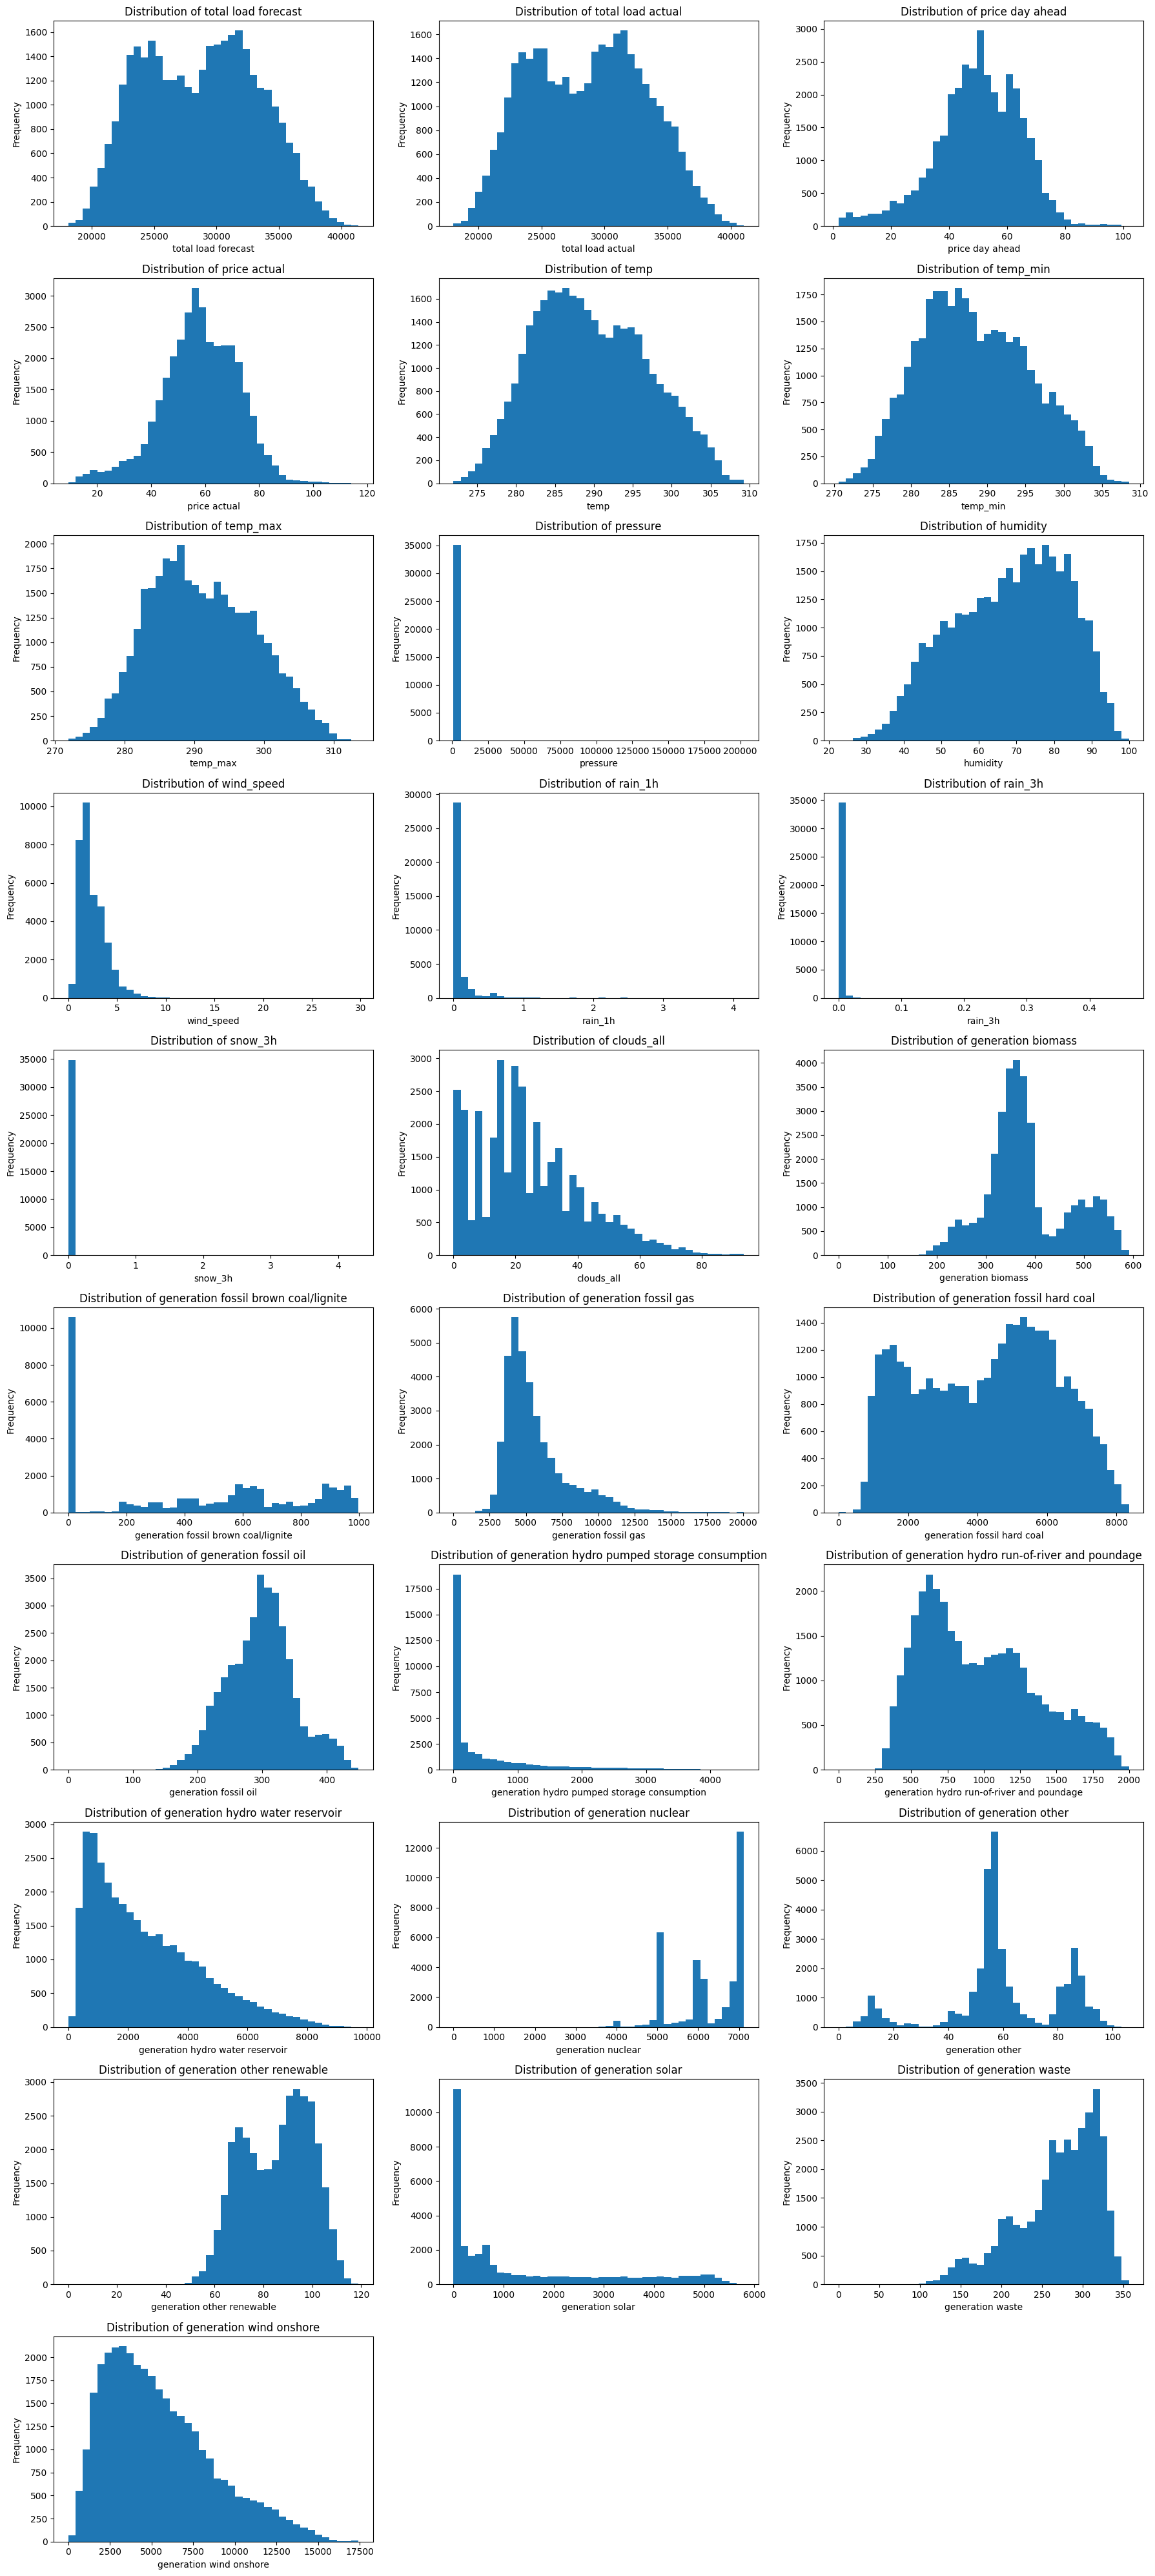

In [ ]:
generation_variables = [
    column for column in combined.columns
    if column.startswith("generation ")
]

distribution_variables = [
    "total load forecast",
    "total load actual",
    "price day ahead",
    "price actual",

    "temp",
    "temp_min",
    "temp_max",
    "pressure",
    "humidity",
    "wind_speed",
    "rain_1h",
    "rain_3h",
    "snow_3h",
    "clouds_all"
]

distribution_variables.extend(generation_variables)

n_cols = 3
n_rows = (len(distribution_variables) + n_cols - 1) // n_cols

fig, axes = plt.subplots(
    n_rows,
    n_cols,
    figsize=(18, 4 * n_rows)
)

axes = axes.flatten()

for i, column in enumerate(distribution_variables):
    axes[i].hist(
        combined[column].dropna(),
        bins=40
    )

    axes[i].set_title(f"Distribution of {column}")
    axes[i].set_xlabel(column)
    axes[i].set_ylabel("Frequency")


# Remove unused subplots
for j in range(len(distribution_variables), len(axes)):
    fig.delaxes(axes[j])

plt.tight_layout()
plt.show()

### Outlier Analysis

Identifies potential outliers across the selected numerical variables using the Interquartile Range (IQR) method. The analysis highlights observations that fall outside the typical range of each variable without treating them as errors automatically.

In [ ]:
outlier_results = []

for column in distribution_variables:
    Q1 = combined[column].quantile(0.25)
    Q3 = combined[column].quantile(0.75)
    IQR = Q3 - Q1

    lower_bound = Q1 - 1.5 * IQR
    upper_bound = Q3 + 1.5 * IQR

    outlier_count = (
        (combined[column] < lower_bound) |
        (combined[column] > upper_bound)
    ).sum()

    outlier_results.append({
        "Variable": column,
        "Q1": Q1,
        "Q3": Q3,
        "IQR": IQR,
        "Lower Bound": lower_bound,
        "Upper Bound": upper_bound,
        "Potential Outliers": outlier_count
    })

outlier_summary = pd.DataFrame(outlier_results)

display(outlier_summary)

,Variable,Q1,Q3,IQR,Lower Bound,Upper Bound,Potential Outliers
0,total load forecast,24793.7500,32263.250,7469.5000,13589.50000,43467.50000,0
1,total load actual,24807.0000,32194.250,7387.2500,13726.12500,43275.12500,0
2,price day ahead,41.4900,60.530,19.0400,12.93000,89.09000,841
3,price actual,49.3475,68.010,18.6625,21.35375,96.00375,699
4,temp,284.0600,295.086,11.0260,267.52100,311.62500,0
5,temp_min,282.9500,293.610,10.6600,266.96000,309.60000,0
6,temp_max,285.3500,296.750,11.4000,268.25000,313.85000,0
7,pressure,1012.8000,1021.000,8.2000,1000.50000,1033.30000,2263
8,humidity,56.8000,80.200,23.4000,21.70000,115.30000,0
9,wind_speed,1.4000,3.200,1.8000,-1.30000,5.90000,830


### Outlier Visualization — Box Plots

Visualizes the spread and potential extreme observations of the selected numerical variables using box plots. The plots complement the IQR-based outlier analysis by showing the median, interquartile range, and observations located beyond the typical range.

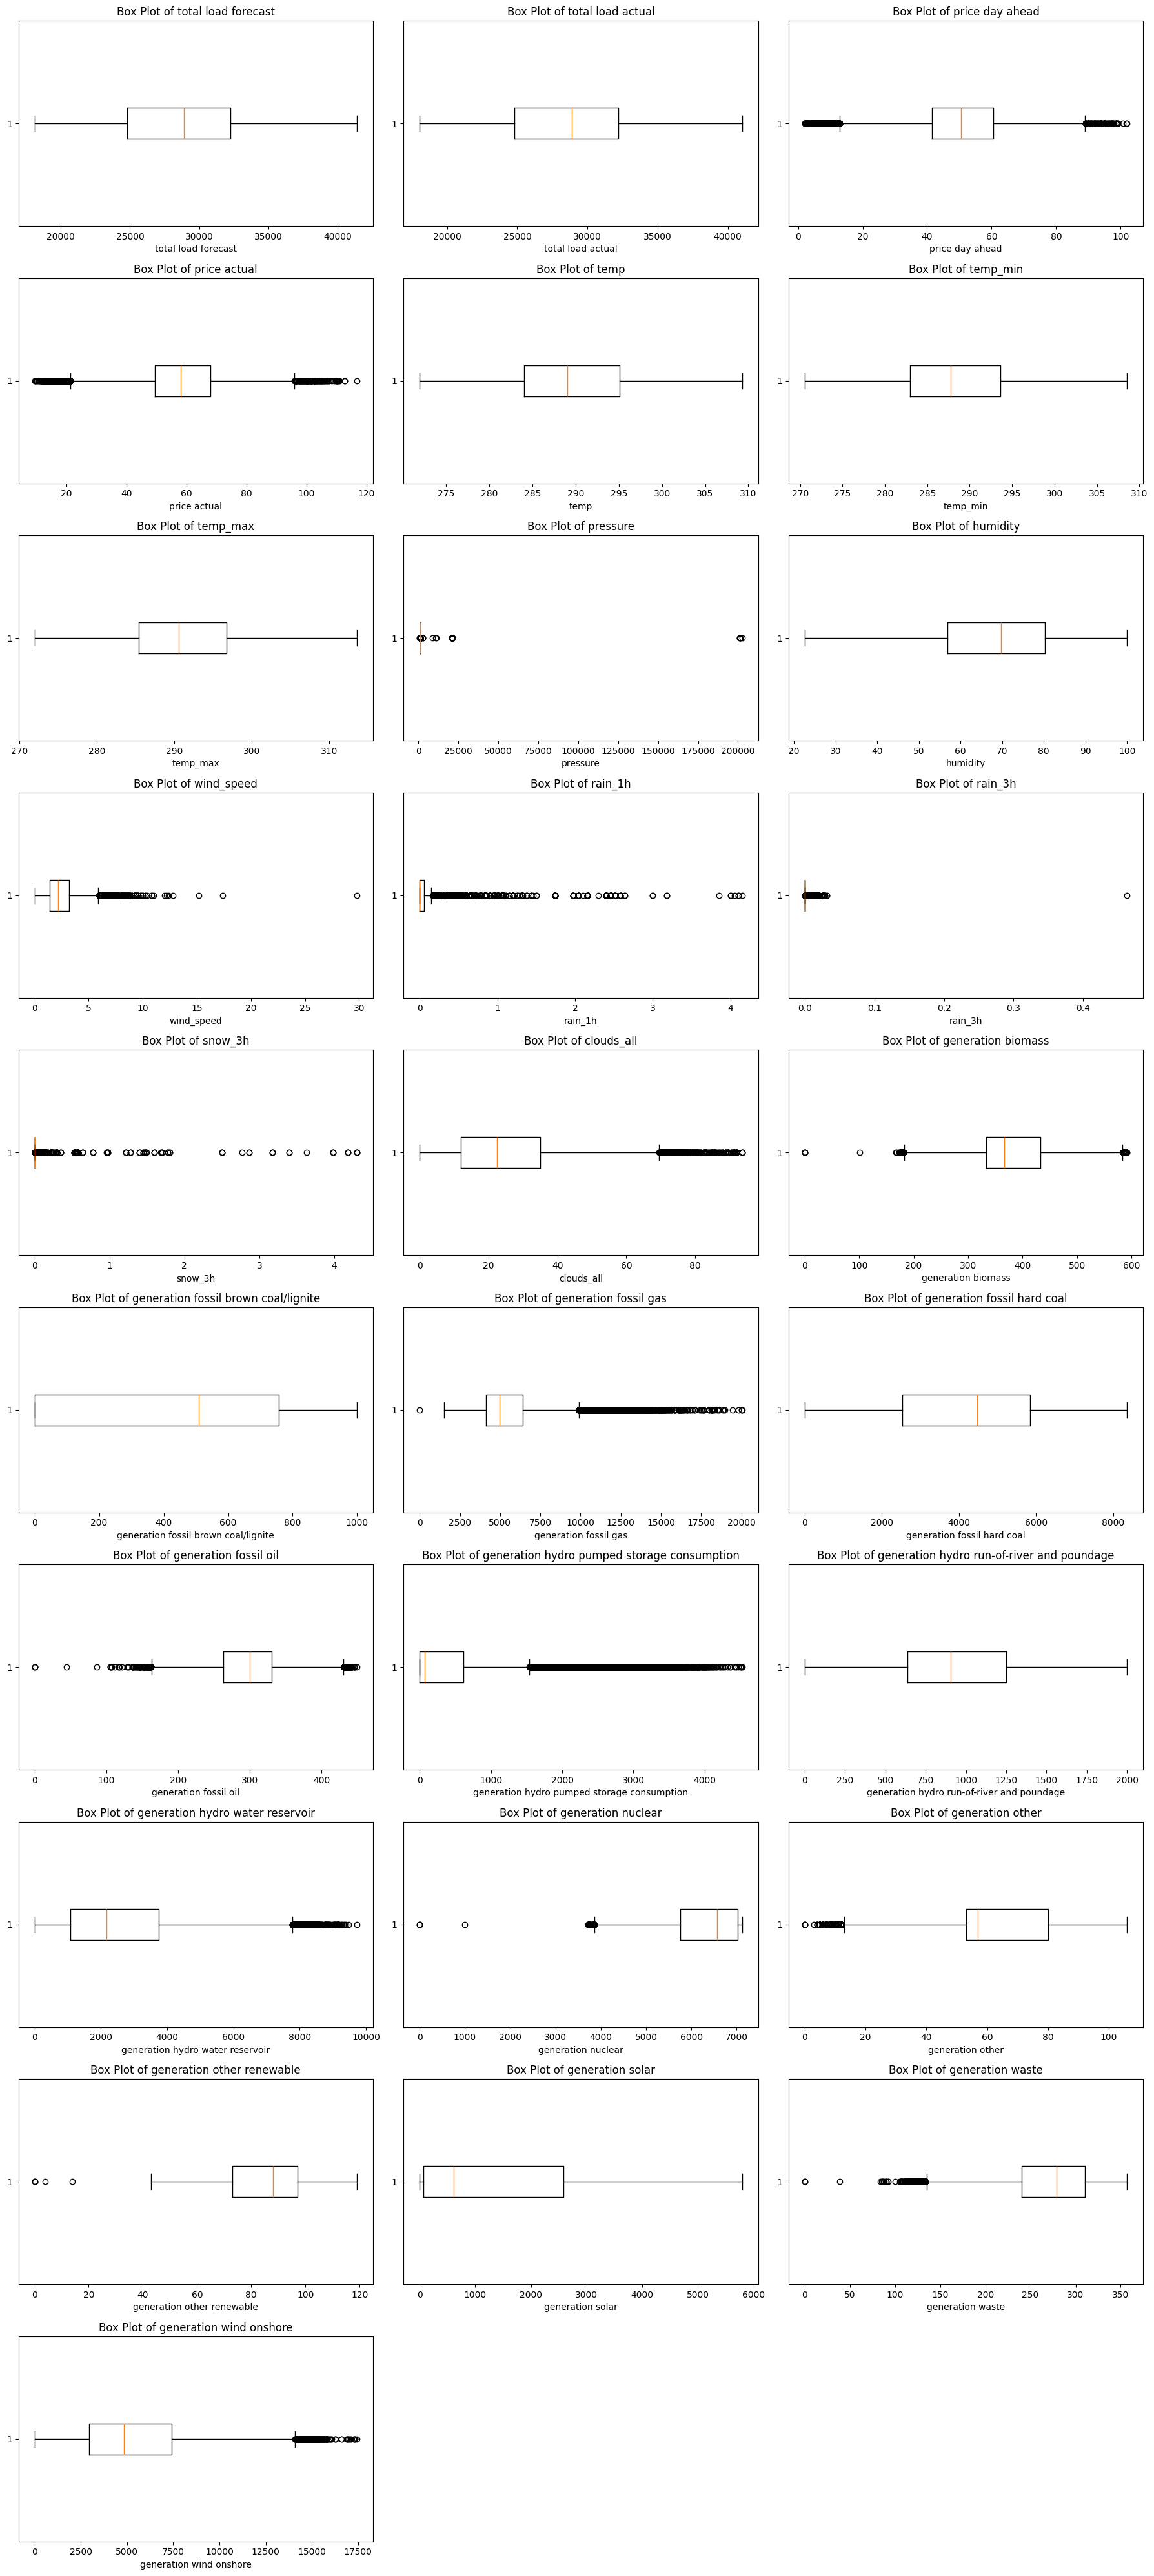

In [ ]:
generation_variables = [
    column for column in combined.columns
    if column.startswith("generation ")
]

distribution_variables = [
    "total load forecast",
    "total load actual",
    "price day ahead",
    "price actual",
    "temp",
    "temp_min",
    "temp_max",
    "pressure",
    "humidity",
    "wind_speed",
    "rain_1h",
    "rain_3h",
    "snow_3h",
    "clouds_all"
]

distribution_variables.extend(generation_variables)

n_cols = 3
n_rows = (len(distribution_variables) + n_cols - 1) // n_cols

fig, axes = plt.subplots(
    n_rows,
    n_cols,
    figsize=(18, 4 * n_rows)
)

axes = axes.flatten()

for i, column in enumerate(distribution_variables):
    axes[i].boxplot(
        combined[column].dropna(),
        vert=False
    )

    axes[i].set_title(f"Box Plot of {column}")
    axes[i].set_xlabel(column)

for j in range(len(distribution_variables), len(axes)):
    fig.delaxes(axes[j])

plt.tight_layout()
plt.show()

### Correlation Analysis

Examines the linear relationships between the selected numerical variables using Pearson correlation. The analysis is used to understand the strength and direction of the relationships, particularly between the explanatory variables and total load actual.

#### Correlation Heatmap

The heatmap presents the Pearson correlation coefficients among the numerical variables included in the cleaned dataset. It provides an overall view of the direction and strength of their linear associations.

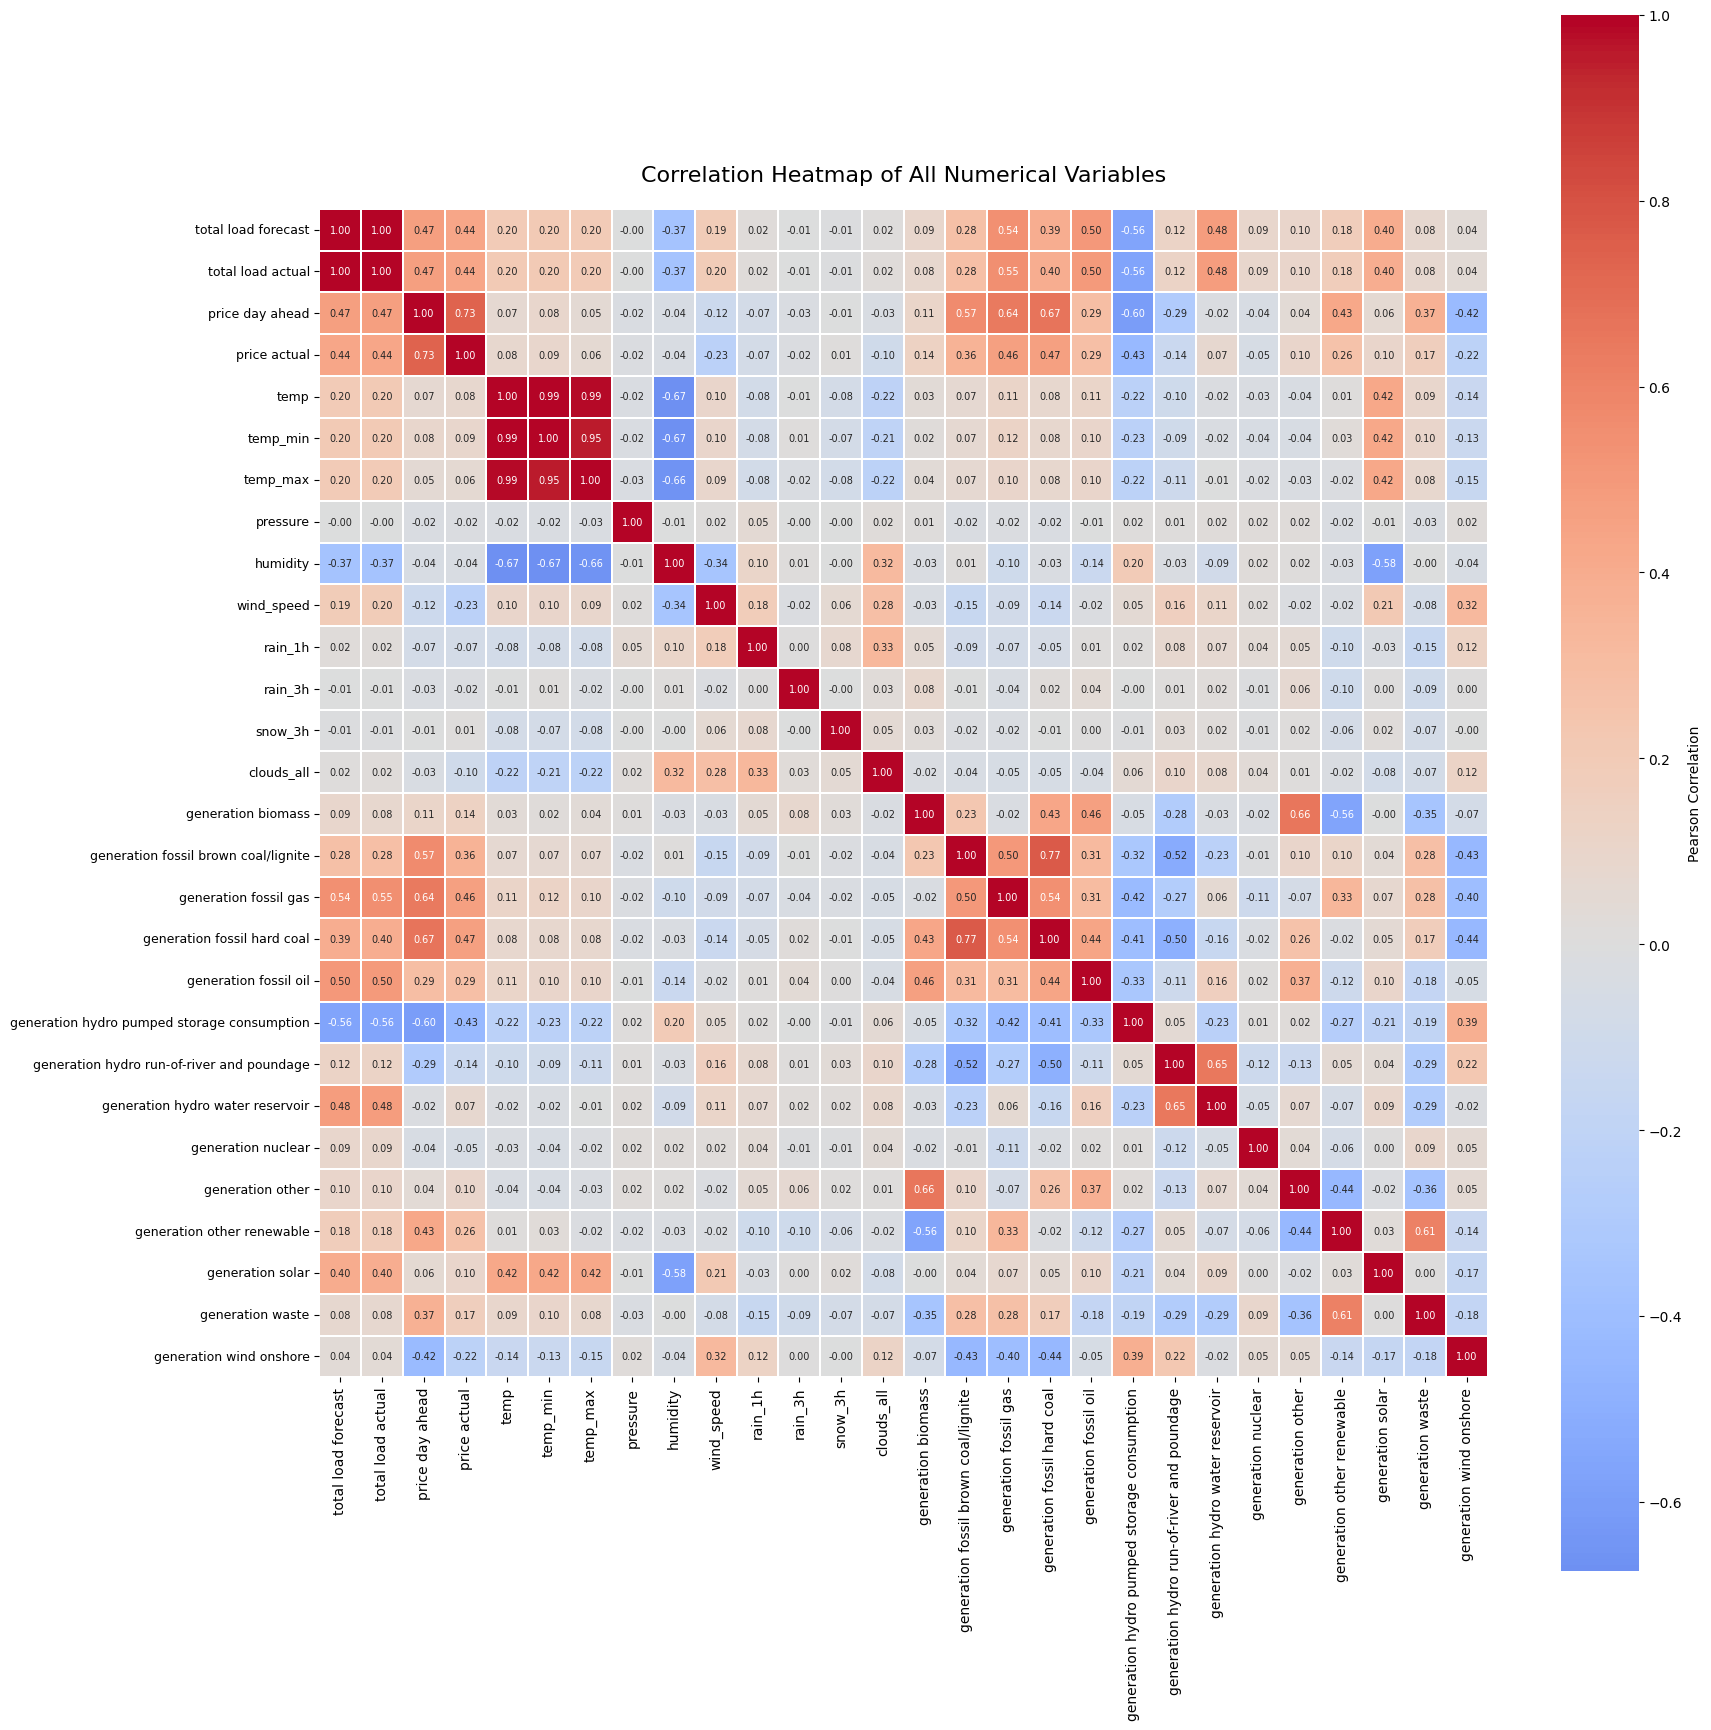

In [ ]:
all_correlation_variables = [
    "total load forecast",
    "total load actual",
    "price day ahead",
    "price actual",
    "temp",
    "temp_min",
    "temp_max",
    "pressure",
    "humidity",
    "wind_speed",
    "rain_1h",
    "rain_3h",
    "snow_3h",
    "clouds_all"
]

all_correlation_variables.extend([
    column for column in combined.columns
    if column.startswith("generation ")
])

correlation_matrix = combined[all_correlation_variables].corr()

fig, ax = plt.subplots(figsize=(18, 18))

sns.heatmap(
    correlation_matrix,
    annot=True,
    fmt=".2f",
    cmap="coolwarm",
    center=0,
    linewidths=0.3,
    square=True,
    annot_kws={"size": 7},
    cbar_kws={"label": "Pearson Correlation"},
    ax=ax
)

ax.set_title(
    "Correlation Heatmap of All Numerical Variables",
    fontsize=16,
    pad=20
)

ax.set_yticklabels(
    ax.get_yticklabels(),
    rotation=0,
    fontsize=9
)

plt.tight_layout()

plt.savefig(
    "correlation_heatmap_all_variables.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

#### Correlation Ranking

Ranks the selected variables according to their Pearson correlation with total load actual. This provides a more focused view of which variables have stronger linear associations with actual electricity demand.

In [ ]:
generation_variables = [
    column for column in combined.columns
    if column.startswith("generation ")
]

correlation_variables = [
    "total load forecast",
    "total load actual",
    "price day ahead",
    "price actual",
    "temp",
    "temp_min",
    "temp_max",
    "pressure",
    "humidity",
    "wind_speed",
    "rain_1h",
    "rain_3h",
    "snow_3h",
    "clouds_all"
]

correlation_variables.extend(generation_variables)

correlation_with_demand = (
    combined[correlation_variables]
    .corr()["total load actual"]
    .drop("total load actual")
    .sort_values(ascending=False)
)

correlation_summary = correlation_with_demand.to_frame(
    name="Correlation with Total Load Actual"
)

display(correlation_summary)

,Correlation with Total Load Actual
total load forecast,0.995096
generation fossil gas,0.548986
generation fossil oil,0.496139
generation hydro water reservoir,0.479491
price day ahead,0.474273
price actual,0.435253
generation fossil hard coal,0.397079
generation solar,0.395511
generation fossil brown coal/lignite,0.280735
temp_min,0.203511


Descriptive statistics were used to examine the main characteristics of electricity demand, electricity prices, weather conditions, and energy generation before applying the predictive and clustering models. The actual electricity demand had a mean of 28,698.28 MW, with values ranging from 18,041 to 41,015 MW. The forecast demand showed a very similar mean of 28,712.13 MW, while the correlation analysis later confirmed a very strong relationship between forecast and actual demand. The mean actual electricity price was 57.88, compared with 49.87 for the day-ahead price.

The distributions showed noticeable differences between variables. Electricity demand had a relatively broad distribution, while variables such as precipitation, snowfall, wind speed, and several energy-generation sources were highly skewed, with many observations concentrated around lower values.

Potential outliers were identified using the IQR method and box plots, particularly in electricity prices, pressure, wind speed, precipitation, and some energy-generation variables. However, these observations were not removed automatically because extreme values may represent genuine electricity generation, market, or weather conditions rather than data-entry errors. Removing them could therefore eliminate valid information from the time series and potentially affect the forecasting results. For this reason, the observations were retained for the subsequent analysis.

The correlation analysis showed that total load forecast had the strongest positive correlation with actual electricity demand (r = 0.995), indicating a very strong linear relationship between forecast and actual demand. Other relatively strong positive correlations were observed for generation fossil gas (r = 0.549), generation fossil oil (r = 0.496), generation hydro water reservoir (r = 0.479), and price day ahead (r = 0.474). In contrast, generation hydro pumped storage consumption showed a relatively strong negative correlation (r = -0.563), while humidity had a moderate negative correlation (r = -0.366). Most weather variables, including pressure, rainfall, and snowfall, showed very weak correlations with actual demand. These results helped identify variables with stronger relationships with electricity demand and supported the subsequent feature selection and modeling stages.

## Dashboard Design and Analytical Visualization

To translate the analytical results into an interactive Business Intelligence environment, two Tableau dashboards were developed. The first dashboard focuses on electricity demand and demand patterns, while the second examines energy generation and the contribution of different energy sources. The dashboards were designed to complement the analytical and clustering stages without reproducing the predictive-model results.

### Dashboard 1 — Electricity Demand & Cluster Analysis

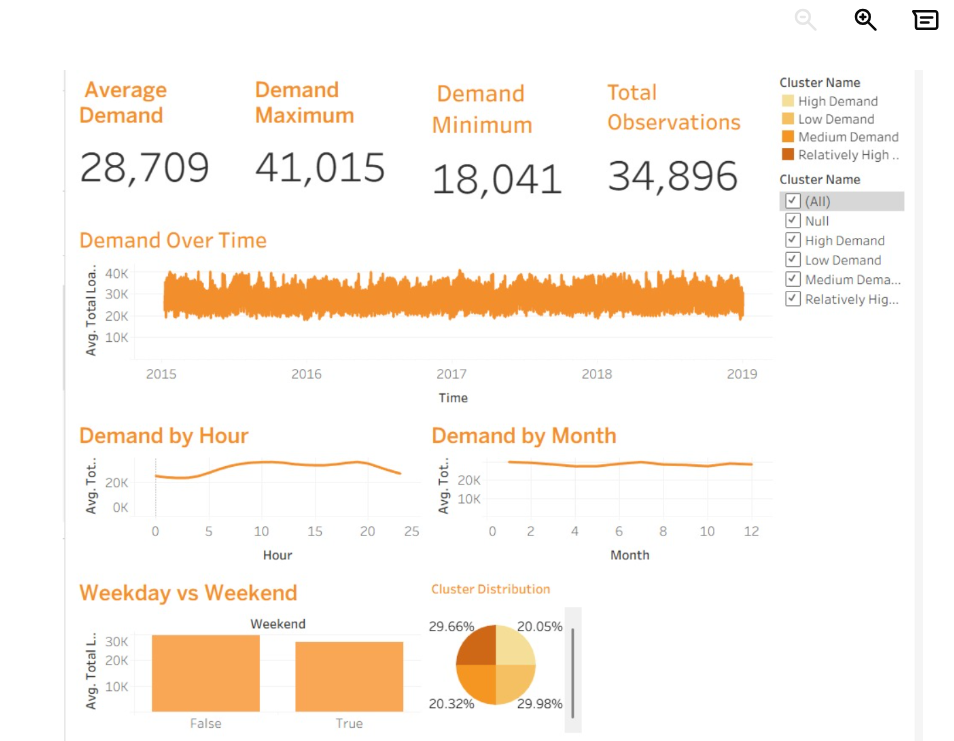

### Dashboard Purpose

This dashboard provides an interactive view of electricity demand over the study period. It combines overall demand indicators, temporal demand patterns, weekday–weekend differences, and the clusters generated through K-Means. Users can select a cluster to examine its corresponding demand behavior without creating separate visualizations for each cluster.

### Dashboard Components

**Average Demand:** Displays the mean electricity demand for the selected data.

**Maximum Demand:** Shows the highest recorded demand value.

**Minimum Demand:** Shows the lowest recorded demand value.

**Total Observations:** Indicates the number of observations represented in the dashboard.

**Demand Over Time:** Illustrates how electricity demand changes throughout the study period.

**Demand by Hour:** Shows the average demand associated with each hour of the day.

**Demand by Month:** Presents the average demand across the months of the year.

**Weekday vs. Weekend:** Compares average electricity demand between weekdays and weekends.

**Cluster Distribution:** Shows the proportion of observations assigned to each demand cluster.

**Cluster Filter:** Allows users to select a specific demand cluster and dynamically update the dashboard visuals.

### Analytical Insights

The dashboard enables users to identify the main temporal characteristics of electricity demand and distinguish between different demand regimes identified by K-Means clustering. The combination of the cluster filter with the temporal visualizations allows demand behavior to be examined at both the overall and cluster levels.

### Dashboard 2 — Energy Generation & Source Analysis

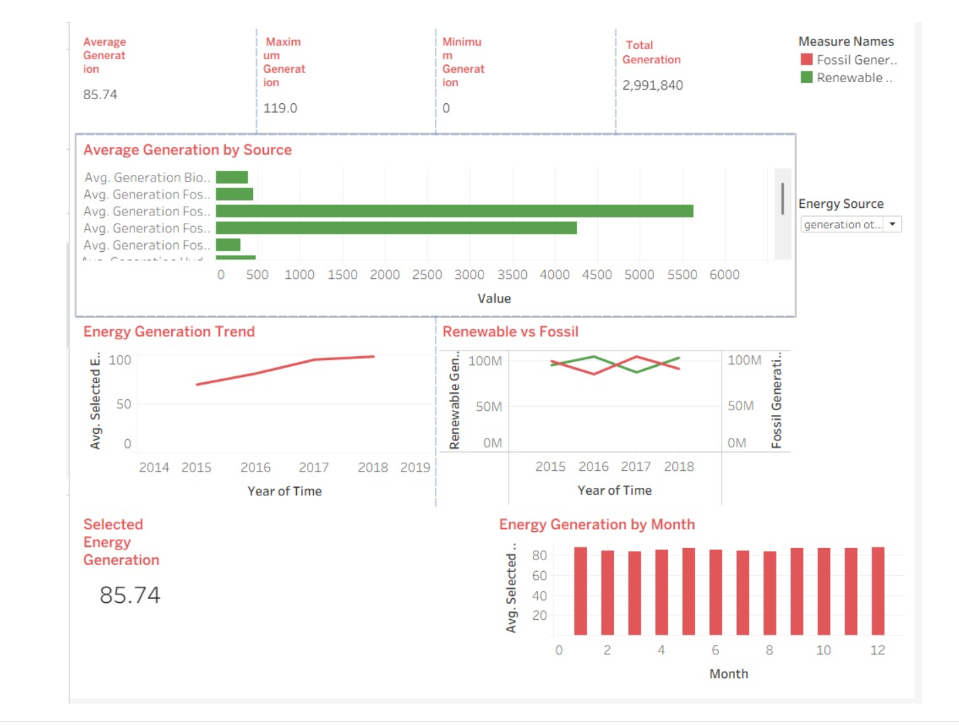

### Dashboard Purpose

The second dashboard shifts the analysis from electricity demand to energy generation. It examines the contribution of different generation sources, their changes over time, and their monthly behavior. An energy-source filter allows the user to select an individual source and dynamically investigate its generation trend.

### Dashboard Components

**Average Generation:** Displays the average generation level for the selected energy source.

**Maximum Generation:** Shows the maximum observed generation value.

**Minimum Generation:** Shows the minimum observed generation value.

**Total Generation:** Presents the overall generation volume represented in the analysis.

**Average Generation by Source:** Compares the average generation levels of the available energy sources.

**Energy Generation Trend:** Displays the temporal evolution of the selected energy source.

**Renewable vs. Fossil:** Compares the generation behavior of renewable and fossil-based sources over time.

**Energy Generation by Month:** Shows the average generation of the selected source across the months of the year.

**Energy Source Filter:** Enables users to select different energy sources and dynamically update the relevant visualizations.

### Analytical Insights

This dashboard provides a comparative view of the energy-generation structure and allows differences between energy sources to be explored interactively. The source-level trend and renewable-versus-fossil comparison help identify changes in generation patterns over time and provide a basis for assessing the direction of the energy mix.

### Advanced Time-Series Analysis

This section examines the temporal structure of actual electricity demand and identifies the main characteristics that are important for time-series forecasting. The analysis focuses on time-series decomposition, temporal dependence, autocorrelation, partial autocorrelation, and stationarity. These steps help determine how the demand series behaves over time, how strongly current demand depends on previous observations, whether its statistical properties remain stable over time. The results provide a statistical basis for selecting and preparing the forecasting models in the next stage.

#### Time-Series Decomposition

Decomposes actual electricity demand into three main components: trend, seasonality, and residuals. The decomposition helps identify the underlying long-term movement, recurring seasonal patterns, and unexplained variation in the demand series.

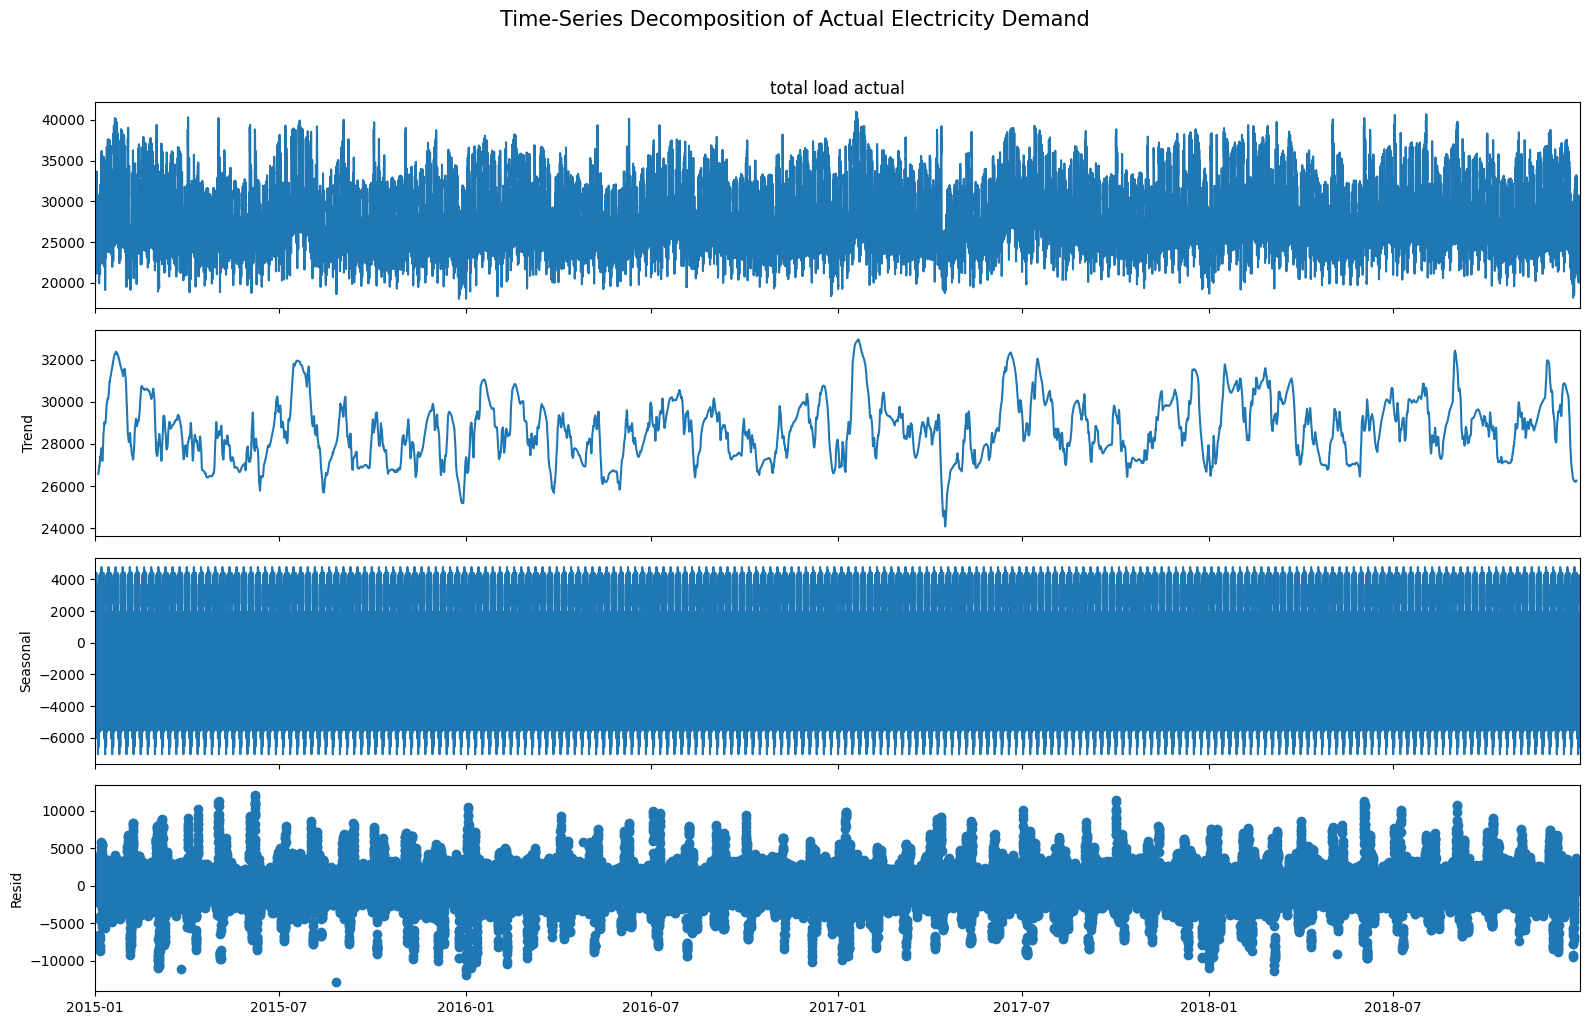

In [ ]:
from statsmodels.tsa.seasonal import seasonal_decompose
import matplotlib.pyplot as plt

demand_series = (
    combined
    .set_index("time")["total load actual"]
    .asfreq("h")
)

decomposition = seasonal_decompose(
    demand_series,
    model="additive",
    period=168
)

fig = decomposition.plot()

fig.set_size_inches(16, 10)

plt.suptitle(
    "Time-Series Decomposition of Actual Electricity Demand",
    fontsize=15,
    y=1.02
)

plt.tight_layout()
plt.show()

#### Autocorrelation and Partial Autocorrelation

The ACF measures the correlation between the current demand and its previous observations at different time lags, while the PACF measures the direct relationship at each lag after accounting for the effects of shorter lags.

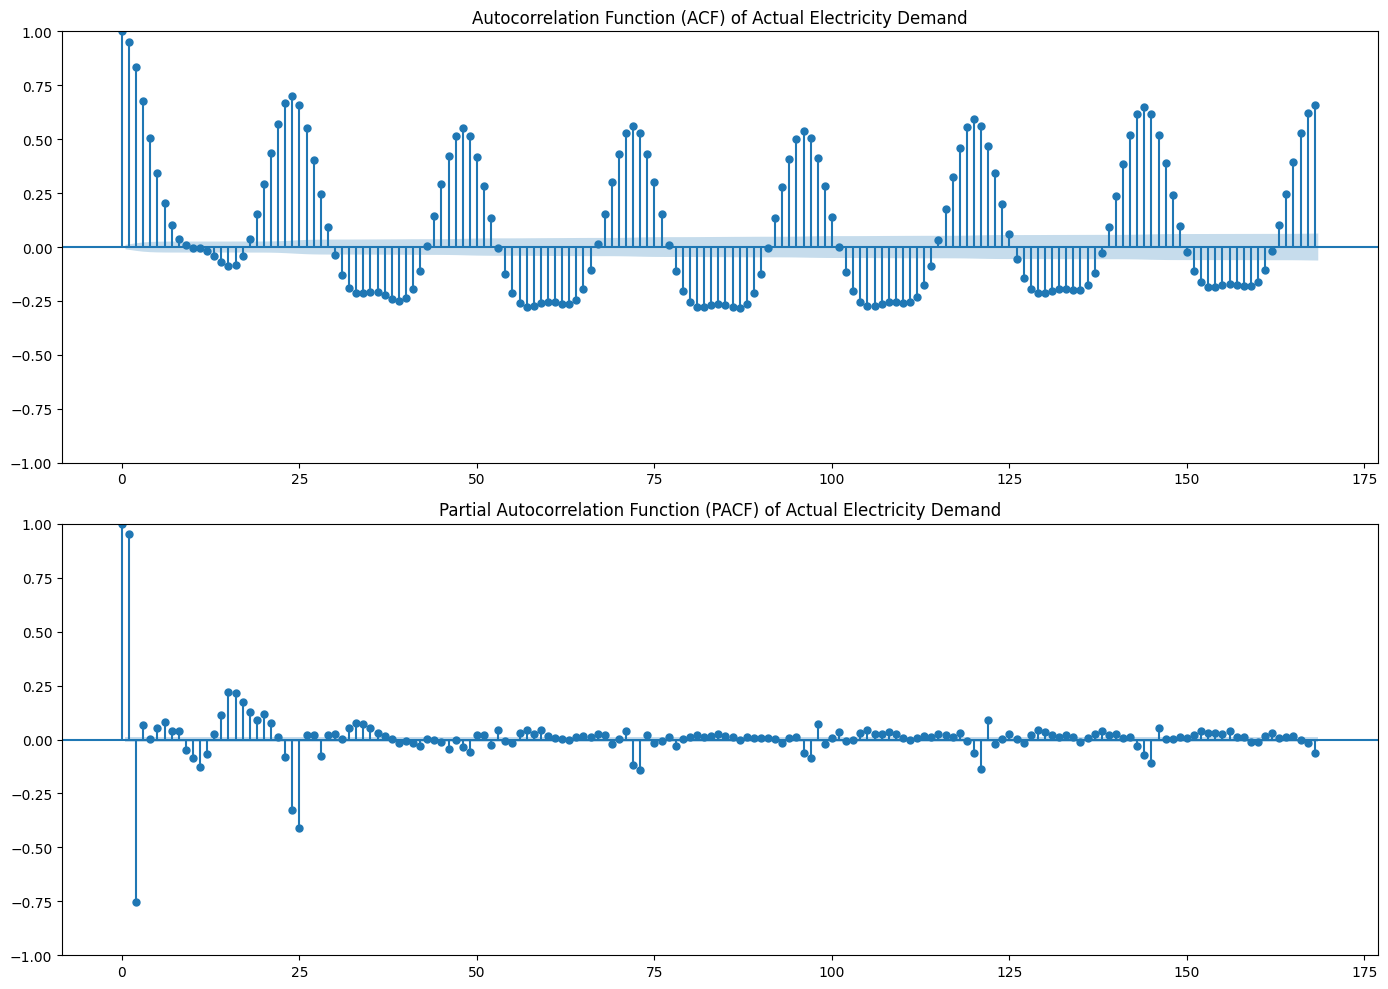

In [ ]:
from statsmodels.graphics.tsaplots import plot_acf, plot_pacf

demand_series = (
    combined
    .set_index("time")["total load actual"]
    .dropna()
)

fig, axes = plt.subplots(2, 1, figsize=(14, 10))

plot_acf(
    demand_series,
    lags=168,
    ax=axes[0]
)

axes[0].set_title(
    "Autocorrelation Function (ACF) of Actual Electricity Demand"
)

plot_pacf(
    demand_series,
    lags=168,
    ax=axes[1],
    method="ywm"
)

axes[1].set_title(
    "Partial Autocorrelation Function (PACF) of Actual Electricity Demand"
)

plt.tight_layout()
plt.show()

#### Stationarity Analysis

Evaluates whether the statistical properties of actual electricity demand remain stable over time. The Augmented Dickey-Fuller (ADF) test is used to test whether the demand series contains a unit root.

In [ ]:
from statsmodels.tsa.stattools import adfuller

demand_series = (
    combined
    .set_index("time")["total load actual"]
    .asfreq("h")
    .dropna()
)

adf_result = adfuller(
    demand_series,
    autolag="AIC"
)

adf_statistic = adf_result[0]
p_value = adf_result[1]
used_lags = adf_result[2]
number_of_observations = adf_result[3]
critical_values = adf_result[4]

adf_summary = pd.DataFrame({
    "Metric": [
        "ADF Statistic",
        "p-value",
        "Used Lags",
        "Number of Observations",
        "1% Critical Value",
        "5% Critical Value",
        "10% Critical Value"
    ],
    "Value": [
        adf_statistic,
        p_value,
        used_lags,
        number_of_observations,
        critical_values["1%"],
        critical_values["5%"],
        critical_values["10%"]
    ]
})

display(adf_summary)

if p_value < 0.05:
    print("Result: Reject H0. The demand series is stationary according to the ADF test.")
else:
    print("Result: Fail to reject H0. The demand series is non-stationary according to the ADF test.")

,Metric,Value
0,ADF Statistic,-21.420316
1,p-value,0.000000
2,Used Lags,52.000000
3,Number of Observations,35011.000000
4,1% Critical Value,-3.430537
5,5% Critical Value,-2.861623
6,10% Critical Value,-2.566814


Result: Reject H0. The demand series is stationary according to the ADF test.


### Results Interpretation

The time-series analysis was conducted to examine the temporal structure of actual electricity demand before applying the forecasting models. The decomposition shows clear seasonal patterns in electricity demand, while the trend component fluctuates over time rather than following a consistent long-term increase or decrease. The residual component contains short-term variations that are not explained by the trend and seasonal components.

The ACF shows strong autocorrelation at several lags, with recurring peaks at approximately 24-hour intervals, indicating a clear daily pattern. The repeated peaks at longer lags also suggest a recurring weekly pattern. The PACF shows a strong relationship at the first lag and additional effects around the daily seasonal lag, confirming that recent demand observations contain useful information for predicting future demand.

The ADF test produced a test statistic of -21.42 with a p-value < 0.001. Since the test statistic is below the critical values and the null hypothesis of a unit root is rejected, the actual electricity demand series is considered stationary according to the ADF test. Therefore, differencing is not required solely to achieve stationarity, although seasonal and autoregressive patterns still need to be considered when selecting the forecasting models.

# Feature Engineering and Data Preprocessing

Prepares the dataset for the modeling stage by transforming the cleaned data into features that capture the main temporal patterns of electricity demand. It creates cyclical time features, lag variables, and rolling statistics to represent daily, weekly, and short-term demand behavior. It also handles the missing values produced by these transformations and divides the data chronologically into training, validation, and testing sets while preserving the time order.

## Cyclical Time Features

ٌepresents hourly and monthly patterns as cyclical variables so that the beginning and end of each cycle remain connected.

In [ ]:
combined["hour_sin"] = np.sin(
    2 * np.pi * combined["Hour"] / 24
)

combined["hour_cos"] = np.cos(
    2 * np.pi * combined["Hour"] / 24
)

combined["month_sin"] = np.sin(
    2 * np.pi * combined["Month"] / 12
)

combined["month_cos"] = np.cos(
    2 * np.pi * combined["Month"] / 12
)

## Lag Features

Creates lagged demand variables to capture short-term, daily, and weekly temporal dependence in electricity demand.

In [ ]:
lags = [
    1,
    2,
    3,
    24,
    48,
    72,
    168
]

for lag in lags:
    combined[f"load_lag_{lag}"] = (
        combined["total load actual"].shift(lag)
    )

## Rolling Features

Calculates rolling demand statistics to capture recent demand level and variability while using only previous observations.

In [ ]:
combined["load_rolling_mean_24"] = (
    combined["total load actual"]
    .shift(1)
    .rolling(window=24)
    .mean()
)

combined["load_rolling_std_24"] = (
    combined["total load actual"]
    .shift(1)
    .rolling(window=24)
    .std()
)

combined["load_rolling_mean_168"] = (
    combined["total load actual"]
    .shift(1)
    .rolling(window=168)
    .mean()
)

## Check Missing Values from Feature Engineering

Examines the missing values created by the lag and rolling calculations. These missing values occur only at the beginning of the series because previous observations are not available.

In [ ]:
missing_values = (
    combined.isnull()
    .sum()
    .sort_values(ascending=False)
)

missing_values = missing_values[
    missing_values > 0
]

display(
    missing_values.to_frame(
        name="Missing Values"
    )
)

,Missing Values
load_rolling_mean_168,168
load_lag_168,168
load_lag_72,72
load_lag_48,48
load_lag_24,24
load_rolling_mean_24,24
load_rolling_std_24,24
load_lag_3,3
load_lag_2,2
load_lag_1,1


## Remove The Missing Values

Removes the initial observations that cannot be used because the required lag and rolling features are unavailable.

In [ ]:
feature_columns = [
    "load_lag_1",
    "load_lag_2",
    "load_lag_3",
    "load_lag_24",
    "load_lag_48",
    "load_lag_72",
    "load_lag_168",
    "load_rolling_mean_24",
    "load_rolling_std_24",
    "load_rolling_mean_168"
]

combined_model = combined.dropna(
    subset=feature_columns
).copy()

In [ ]:
remaining_missing = (
    combined_model[feature_columns]
    .isnull()
    .sum()
)

display(
    remaining_missing[
        remaining_missing > 0
    ]
)

,0


## Chronological Train–Validation–Test Split

Divides the dataset chronologically into training, validation, and testing sets. The chronological order is preserved to avoid using future observations during model development.

In [ ]:
combined_model = combined_model.sort_values("time").reset_index(drop=True)

n = len(combined_model)

train_end = int(n * 0.70)
validation_end = int(n * 0.85)

train_data = combined_model.iloc[:train_end].copy()
validation_data = combined_model.iloc[train_end:validation_end].copy()
test_data = combined_model.iloc[validation_end:].copy()

print("Training Set:", train_data.shape)
print("Validation Set:", validation_data.shape)
print("Testing Set:", test_data.shape)

Training Set: (24427, 51)
Validation Set: (5234, 51)
Testing Set: (5235, 51)


## Dataset Split Summary

Summarizes the time range and number of observations in each dataset to verify that the chronological split was performed correctly.

In [ ]:
split_summary = pd.DataFrame({
    "Dataset": [
        "Training",
        "Validation",
        "Testing"
    ],
    "Start": [
        train_data["time"].min(),
        validation_data["time"].min(),
        test_data["time"].min()
    ],
    "End": [
        train_data["time"].max(),
        validation_data["time"].max(),
        test_data["time"].max()
    ],
    "Observations": [
        len(train_data),
        len(validation_data),
        len(test_data)
    ]
})

display(split_summary)

,Dataset,Start,End,Observations
0,Training,2015-01-07 23:00:00+00:00,2017-10-21 17:00:00+00:00,24427
1,Validation,2017-10-21 18:00:00+00:00,2018-05-27 19:00:00+00:00,5234
2,Testing,2018-05-27 20:00:00+00:00,2018-12-31 22:00:00+00:00,5235


## One-Hot Encoding of Categorical Feature

Converts the categorical Season variable into one-hot encoded variables after splitting the data. The encoder is fitted only on the training set and then applied to the validation and testing sets to prevent data leakage. The first category is dropped as the reference category.

In [ ]:
from sklearn.preprocessing import OneHotEncoder

encoder = OneHotEncoder(
    drop="first",
    handle_unknown="ignore",
    sparse_output=False
)

season_train_encoded = encoder.fit_transform(
    train_data[["Season"]]
)

season_validation_encoded = encoder.transform(
    validation_data[["Season"]]
)

season_test_encoded = encoder.transform(
    test_data[["Season"]]
)

season_columns = encoder.get_feature_names_out(
    ["Season"]
)

season_train_df = pd.DataFrame(
    season_train_encoded,
    index=train_data.index,
    columns=season_columns
)

season_validation_df = pd.DataFrame(
    season_validation_encoded,
    index=validation_data.index,
    columns=season_columns
)

season_test_df = pd.DataFrame(
    season_test_encoded,
    index=test_data.index,
    columns=season_columns
)

train_data_encoded = pd.concat(
    [
        train_data.drop(columns=["Season"]),
        season_train_df
    ],
    axis=1
)

validation_data_encoded = pd.concat(
    [
        validation_data.drop(columns=["Season"]),
        season_validation_df
    ],
    axis=1
)

test_data_encoded = pd.concat(
    [
        test_data.drop(columns=["Season"]),
        season_test_df
    ],
    axis=1
)

## Binary Feature Encoding

Converts the binary Weekend variable into a numerical 0–1 representation for use in the correlation analysis, multicollinearity assessment, and predictive models.

In [ ]:
for df in [
    train_data_encoded,
    validation_data_encoded,
    test_data_encoded
]:
    df["Weekend"] = df["Weekend"].astype(int)

In [ ]:
print(train_data_encoded["Weekend"].dtype)
print(train_data_encoded["Weekend"].unique())

int64
[0 1]


## Feature Selection

Selects the relevant predictors from the engineered dataset and removes variables that may be redundant or unsuitable for modeling. The selection is performed using the training data only to avoid information leakage.

### Correlation Analysis

Examines the linear correlation between each predictor and electricity demand using the training data.

In [ ]:
target = "total load actual"

correlation_with_target = (
    train_data_encoded[feature_columns + [target]]
    .corr(numeric_only=True)[target]
    .drop(target)
    .sort_values(key=abs, ascending=False)
)

display(
    correlation_with_target.to_frame(
        "Correlation with Target"
    )
)

,Correlation with Target
load_lag_1,0.950803
load_lag_2,0.832544
load_lag_24,0.700905
load_lag_3,0.675722
load_lag_168,0.653775
load_lag_72,0.570318
load_lag_48,0.550882
load_rolling_mean_24,0.457038
load_rolling_std_24,0.269166
load_rolling_mean_168,0.260059


### Multicollinearity Analysis

Examines multicollinearity between predictors using the Variance Inflation Factor (VIF).

In [ ]:
from statsmodels.stats.outliers_influence import variance_inflation_factor

X_train = train_data_encoded.drop(
    columns=["total load actual", "time"],
    errors="ignore"
).copy()

X_vif = X_train.replace(
    [np.inf, -np.inf],
    np.nan
).dropna()

X_vif_values = X_vif.to_numpy(
    dtype=np.float64
)

vif_data = pd.DataFrame({
    "Feature": X_vif.columns,
    "VIF": [
        variance_inflation_factor(
            X_vif_values,
            i
        )
        for i in range(X_vif_values.shape[1])
    ]
})

vif_data = (
    vif_data
    .sort_values(
        "VIF",
        ascending=False
    )
    .reset_index(drop=True)
)

display(vif_data)

,Feature,VIF
0,temp,1.611011e+06
1,temp_min,4.676536e+05
2,temp_max,3.703331e+05
3,load_lag_2,3.831934e+03
4,load_lag_1,3.389999e+03
5,forecast wind onshore day ahead,1.876149e+03
6,generation wind onshore,1.862639e+03
7,load_lag_3,1.415012e+03
8,total load forecast,1.267135e+03
9,load_rolling_mean_168,1.016939e+03


## Define Predictors and Feature Reduction

Reduces redundant and less informative predictors while retaining the main temporal and explanatory information needed for electricity-demand forecasting.

In [ ]:
target = "total load actual"

X_train = train_data_encoded.drop(
    columns=[target, "time"],
    errors="ignore"
).copy()

X_validation = validation_data_encoded.drop(
    columns=[target, "time"],
    errors="ignore"
).copy()

X_test = test_data_encoded.drop(
    columns=[target, "time"],
    errors="ignore"
).copy()

y_train = train_data_encoded[target].copy()
y_validation = validation_data_encoded[target].copy()
y_test = test_data_encoded[target].copy()

In [ ]:
features_to_remove = [
    "total load forecast",
    "total_load_actual_imputed",
    "load_lag_2",
    "load_lag_3",
    "generation wind onshore",
    "forecast wind onshore day ahead",
    "load_rolling_mean_168",
    "generation solar",
    "Day",
    "rain_1h",
    "rain_3h",
    "snow_3h",
    "pressure",
    "generation waste",
    "generation biomass",
    "generation other",
    "price actual"
]

X_train_reduced = X_train.drop(
    columns=features_to_remove,
    errors="ignore"
)

X_validation_reduced = X_validation.drop(
    columns=features_to_remove,
    errors="ignore"
)

X_test_reduced = X_test.drop(
    columns=features_to_remove,
    errors="ignore"
)

print(
    "Features before reduction:",
    X_train.shape[1]
)

print(
    "Features after reduction:",
    X_train_reduced.shape[1]
)

print(
    "Removed features:",
    X_train.shape[1] - X_train_reduced.shape[1]
)

print(
    "Training and Validation features identical:",
    list(X_train_reduced.columns)
    == list(X_validation_reduced.columns)
)

print(
    "Training and Testing features identical:",
    list(X_train_reduced.columns)
    == list(X_test_reduced.columns)
)

Features before reduction: 51
Features after reduction: 34
Removed features: 17
Training and Validation features identical: True
Training and Testing features identical: True


# Advanced Analytics and AI Modeling

Different statistical and machine learning techniques were applied to analyze and predict electricity demand from multiple perspectives. The selected methods were chosen based on the characteristics of the dataset, including temporal dependencies, correlated predictors, engineered lag features, and the possibility of both linear and nonlinear relationships. The analysis includes supervised regression models for electricity demand forecasting and an unsupervised clustering approach for identifying different patterns within the observations.

## Supervised Models
### 1. Ridge Regression

Ridge Regression was applied to model electricity demand within a regularized linear framework. It was selected to address potential multicollinearity among the predictors, particularly among the lag-based, weather, and electricity-related variables. The L2 regularization penalty shrinks the regression coefficients and helps improve model stability when predictors are highly correlated (Hoerl & Kennard, 1970).

### 2. XGBoost Regression

XGBoost Regression was applied to capture nonlinear relationships and interactions between the engineered predictors and electricity demand. The model uses gradient-boosted decision trees and is well suited to structured datasets with complex relationships between variables. XGBoost was also tuned using different hyperparameter configurations to identify the configuration providing the strongest validation performance (Chen & Guestrin, 2016).

## Regression Evaluation Metrics

MAE, RMSE, MAPE, and R² were used to evaluate the predictive performance of the regression models. The same chronological testing period was maintained for both models to provide a consistent out-of-sample comparison. RMSE was used as the primary model-selection criterion during hyperparameter tuning because it gives greater weight to larger forecasting errors, while MAE, MAPE, and R² were retained as complementary performance measures.

## Unsupervised Model
### Electricity Demand Clustering

K-Means clustering was applied to identify groups of observations with similar characteristics within the electricity demand dataset. Unlike the supervised regression models, the clustering procedure does not use total load actual as a prediction target. Instead, observations are grouped according to the similarity of their selected features after standardization by minimizing within-cluster variation (MacQueen, 1967).

## Supervised Models

## Ridge Regression Model

### Feature Scaling

Standardizes the selected predictors before fitting Ridge Regression. The scaler is fitted only on the training data and then applied to the validation and testing sets.

In [ ]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()

X_train_ridge = scaler.fit_transform(
    X_train_reduced
)

X_validation_ridge = scaler.transform(
    X_validation_reduced
)

X_test_ridge = scaler.transform(
    X_test_reduced
)

### Ridge Hyperparameter Tuning

Evaluates different regularization strengths and selects the value of alpha that provides the lowest validation RMSE, as RMSE directly measures prediction error and penalizes large errors more strongly.

In [ ]:
from sklearn.linear_model import Ridge
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

ridge_alphas = [
    0.001,
    0.01,
    0.1,
    1,
    10,
    100,
    1000
]

ridge_results = []

for alpha in ridge_alphas:

    ridge_model = Ridge(
        alpha=alpha
    )

    ridge_model.fit(
        X_train_ridge,
        y_train
    )

    validation_forecast = ridge_model.predict(
        X_validation_ridge
    )

    mae = mean_absolute_error(
        y_validation,
        validation_forecast
    )

    rmse = np.sqrt(
        mean_squared_error(
            y_validation,
            validation_forecast
        )
    )

    mape = (
        np.mean(
            np.abs(
                (y_validation - validation_forecast)
                / y_validation
            )
        ) * 100
    )

    r2 = r2_score(
        y_validation,
        validation_forecast
    )

    ridge_results.append({
        "alpha": alpha,
        "MAE": mae,
        "RMSE": rmse,
        "MAPE": mape,
        "R²": r2
    })

ridge_results = (
    pd.DataFrame(ridge_results)
    .sort_values(
        "RMSE"
    )
    .reset_index(drop=True)
)

display(ridge_results)

,alpha,MAE,RMSE,MAPE,R²
0,0.001,751.604200,983.591305,2.606001,0.956623
1,0.010,751.604196,983.591319,2.606001,0.956623
2,0.100,751.604167,983.591462,2.606002,0.956623
3,1.000,751.604575,983.593362,2.606018,0.956623
4,10.000,751.658564,983.643725,2.606371,0.956618
5,100.000,753.212085,985.073135,2.613644,0.956492
6,1000.000,793.992030,1031.107611,2.767867,0.952330


### Select the Best Ridge Configuration

Selects the Ridge configuration with the lowest validation RMSE.

In [ ]:
best_ridge_row = ridge_results.iloc[0]

best_ridge_alpha = best_ridge_row["alpha"]

print("Best Ridge Alpha:", best_ridge_alpha)
print("Validation MAE:", best_ridge_row["MAE"])
print("Validation RMSE:", best_ridge_row["RMSE"])
print("Validation MAPE:", best_ridge_row["MAPE"])
print("Validation R²:", best_ridge_row["R²"])

Best Ridge Alpha: 0.001
Validation MAE: 751.6041998753349
Validation RMSE: 983.5913052633298
Validation MAPE: 2.6060006603865404
Validation R²: 0.9566227419009805


### Ridge Overfitting Check

Compares the training and validation performance to check whether the selected Ridge model is overfitting.

In [ ]:
best_ridge = Ridge(
    alpha=0.001
)

best_ridge.fit(
    X_train_ridge,
    y_train
)

# Predictions
ridge_train_forecast = best_ridge.predict(
    X_train_ridge
)

ridge_validation_forecast = best_ridge.predict(
    X_validation_ridge
)


# Evaluation function
def evaluate_ridge(
    y_true,
    y_pred
):

    mae = mean_absolute_error(
        y_true,
        y_pred
    )

    rmse = np.sqrt(
        mean_squared_error(
            y_true,
            y_pred
        )
    )

    mape = (
        np.mean(
            np.abs(
                (y_true - y_pred)
                / y_true
            )
        ) * 100
    )

    r2 = r2_score(
        y_true,
        y_pred
    )

    return mae, rmse, mape, r2


# Training results
ridge_train_mae, \
ridge_train_rmse, \
ridge_train_mape, \
ridge_train_r2 = evaluate_ridge(
    y_train,
    ridge_train_forecast
)


# Validation results
ridge_validation_mae, \
ridge_validation_rmse, \
ridge_validation_mape, \
ridge_validation_r2 = evaluate_ridge(
    y_validation,
    ridge_validation_forecast
)


# Results table
ridge_overfitting_results = pd.DataFrame({
    "Dataset": [
        "Training",
        "Validation"
    ],
    "MAE": [
        ridge_train_mae,
        ridge_validation_mae
    ],
    "RMSE": [
        ridge_train_rmse,
        ridge_validation_rmse
    ],
    "MAPE": [
        ridge_train_mape,
        ridge_validation_mape
    ],
    "R²": [
        ridge_train_r2,
        ridge_validation_r2
    ]
})

display(
    ridge_overfitting_results
)

,Dataset,MAE,RMSE,MAPE,R²
0,Training,709.448559,937.828137,2.496843,0.957207
1,Validation,751.604200,983.591305,2.606001,0.956623


### Ridge Test Evaluation

Evaluates the final Ridge model on the unseen test dataset to measure its final generalization performance.

In [ ]:
ridge_test_forecast = best_ridge.predict(
    X_test_ridge
)

ridge_test_mae = mean_absolute_error(
    y_test,
    ridge_test_forecast
)

ridge_test_rmse = np.sqrt(
    mean_squared_error(
        y_test,
        ridge_test_forecast
    )
)

ridge_test_mape = (
    np.mean(
        np.abs(
            (y_test - ridge_test_forecast)
            / y_test
        )
    ) * 100
)

ridge_test_r2 = r2_score(
    y_test,
    ridge_test_forecast
)

print("Ridge Test Results")
print("MAE:", ridge_test_mae)
print("RMSE:", ridge_test_rmse)
print("MAPE:", ridge_test_mape)
print("R²:", ridge_test_r2)

Ridge Test Results
MAE: 701.5597349079276
RMSE: 907.4404009378975
MAPE: 2.4549177611987107
R²: 0.9607752931618628


### Ridge Regression Results

Ridge regression was evaluated using different values of the regularization parameter α. The validation results were almost unchanged for small α values, with the best configuration obtained at α = 0.001. This configuration achieved a validation MAE of 751.60, RMSE of 983.59, MAPE of 2.61%, and R² of 0.9566.

The model achieved slightly better performance on the test set, with a MAE of 701.56, RMSE of 907.44, MAPE of 2.45%, and R² of 0.9608. The similarity between the validation and test results suggests that the Ridge model maintained relatively stable predictive performance on unseen data.

## XGBoost Model

### XGBoost Hyperparameter Tuning

Searches directly for the XGBoost configuration that provides the best validation performance. The tuning process evaluates different combinations of tree complexity, learning rate, number of estimators, minimum child weight, row subsampling, and feature subsampling. The testing set remains completely unseen during this process.

In [ ]:
from xgboost import XGBRegressor
from sklearn.model_selection import ParameterGrid
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

tuning_grid = {
    "n_estimators": [300, 500, 700],
    "learning_rate": [0.03, 0.05, 0.1],
    "max_depth": [4, 6, 8],
    "min_child_weight": [1, 3],
    "subsample": [0.8],
    "colsample_bytree": [0.8]
}

In [ ]:
tuning_results = []

for params in ParameterGrid(tuning_grid):

    print("Testing:", params)

    model = XGBRegressor(
        objective="reg:squarederror",
        random_state=42,
        n_jobs=-1,
        **params
    )

    # Train using reduced features
    model.fit(
        X_train_reduced,
        y_train
    )

    # Validation prediction
    validation_forecast = model.predict(
        X_validation_reduced
    )

    # Evaluation metrics
    mae = mean_absolute_error(
        y_validation,
        validation_forecast
    )

    rmse = np.sqrt(
        mean_squared_error(
            y_validation,
            validation_forecast
        )
    )

    mape = (
        np.mean(
            np.abs(
                (y_validation - validation_forecast)
                / y_validation
            )
        ) * 100
    )

    r2 = r2_score(
        y_validation,
        validation_forecast
    )

    tuning_results.append({
        **params,
        "MAE": mae,
        "RMSE": rmse,
        "MAPE": mape,
        "R²": r2
    })

# Sort configurations by validation RMSE
xgb_tuning_results = (
    pd.DataFrame(tuning_results)
    .sort_values("RMSE")
    .reset_index(drop=True)
)

display(
    xgb_tuning_results.head(10)
)

Testing: {'colsample_bytree': 0.8, 'learning_rate': 0.03, 'max_depth': 4, 'min_child_weight': 1, 'n_estimators': 300, 'subsample': 0.8}
Testing: {'colsample_bytree': 0.8, 'learning_rate': 0.03, 'max_depth': 4, 'min_child_weight': 1, 'n_estimators': 500, 'subsample': 0.8}
Testing: {'colsample_bytree': 0.8, 'learning_rate': 0.03, 'max_depth': 4, 'min_child_weight': 1, 'n_estimators': 700, 'subsample': 0.8}
Testing: {'colsample_bytree': 0.8, 'learning_rate': 0.03, 'max_depth': 4, 'min_child_weight': 3, 'n_estimators': 300, 'subsample': 0.8}
Testing: {'colsample_bytree': 0.8, 'learning_rate': 0.03, 'max_depth': 4, 'min_child_weight': 3, 'n_estimators': 500, 'subsample': 0.8}
Testing: {'colsample_bytree': 0.8, 'learning_rate': 0.03, 'max_depth': 4, 'min_child_weight': 3, 'n_estimators': 700, 'subsample': 0.8}
Testing: {'colsample_bytree': 0.8, 'learning_rate': 0.03, 'max_depth': 6, 'min_child_weight': 1, 'n_estimators': 300, 'subsample': 0.8}
Testing: {'colsample_bytree': 0.8, 'learning_rat

,colsample_bytree,learning_rate,max_depth,min_child_weight,n_estimators,subsample,MAE,RMSE,MAPE,R²
0,0.8,0.03,8,1,700,0.8,373.968308,546.243201,1.320326,0.986622
1,0.8,0.03,8,1,500,0.8,375.838644,547.817898,1.325562,0.986544
2,0.8,0.03,6,1,700,0.8,379.633424,555.337221,1.341058,0.986172
3,0.8,0.03,8,1,300,0.8,385.147797,557.520923,1.357049,0.986063
4,0.8,0.05,6,1,700,0.8,382.965617,560.350362,1.349202,0.985922
5,0.8,0.03,8,3,700,0.8,379.589082,561.230013,1.344955,0.985877
6,0.8,0.03,6,1,500,0.8,386.864817,561.652875,1.365186,0.985856
7,0.8,0.03,8,3,500,0.8,382.067865,563.332013,1.351912,0.985771
8,0.8,0.05,6,1,500,0.8,387.953238,565.263690,1.365411,0.985674
9,0.8,0.05,8,1,700,0.8,391.353793,566.432798,1.382058,0.985614


### Best XGBoost Configuration

Evaluates each XGBoost configuration using MAE, RMSE, MAPE, and R². The primary model-selection criterion is validation RMSE because it penalizes large forecasting errors more strongly, while MAE, MAPE, and R² are retained as complementary performance measures. The configuration with the lowest validation RMSE is selected as the final candidate.

In [ ]:
best_xgb_params = (
    xgb_tuning_results
    .iloc[0]
)

print("Best XGBoost Parameters")

print(
    "n_estimators:",
    int(best_xgb_params["n_estimators"])
)

print(
    "learning_rate:",
    best_xgb_params["learning_rate"]
)

print(
    "max_depth:",
    int(best_xgb_params["max_depth"])
)

print(
    "min_child_weight:",
    int(best_xgb_params["min_child_weight"])
)

print(
    "subsample:",
    best_xgb_params["subsample"]
)

print(
    "colsample_bytree:",
    best_xgb_params["colsample_bytree"]
)

print(
    "Validation MAE:",
    best_xgb_params["MAE"]
)

print(
    "Validation RMSE:",
    best_xgb_params["RMSE"]
)

print(
    "Validation MAPE:",
    best_xgb_params["MAPE"]
)

print(
    "Validation R²:",
    best_xgb_params["R²"]
)

Best XGBoost Parameters
n_estimators: 700
learning_rate: 0.03
max_depth: 8
min_child_weight: 1
subsample: 0.8
colsample_bytree: 0.8
Validation MAE: 373.9683078041412
Validation RMSE: 546.2432011598895
Validation MAPE: 1.3203260097635052
Validation R²: 0.9866215800736208


### Final XGBoost Model

Constructs the XGBoost model using the best hyperparameters identified during validation. The model is trained on the training dataset and is then used to assess generalization before the final test evaluation.

In [ ]:
best_xgb = XGBRegressor(
    objective="reg:squarederror",
    n_estimators=int(best_xgb_params["n_estimators"]),
    learning_rate=best_xgb_params["learning_rate"],
    max_depth=int(best_xgb_params["max_depth"]),
    min_child_weight=int(best_xgb_params["min_child_weight"]),
    subsample=best_xgb_params["subsample"],
    colsample_bytree=best_xgb_params["colsample_bytree"],
    random_state=42,
    n_jobs=-1,
    enable_categorical=True
)

best_xgb.fit(
    X_train_reduced,
    y_train
)

XGBRegressor(base_score=None, booster=None, callbacks=None,
             colsample_bylevel=None, colsample_bynode=None,
             colsample_bytree=np.float64(0.8), device=None,
             early_stopping_rounds=None, enable_categorical=True,
             eval_metric=None, feature_types=None, feature_weights=None,
             gamma=None, grow_policy=None, importance_type=None,
             interaction_constraints=None, learning_rate=np.float64(0.03),
             max_bin=None, max_cat_threshold=None, max_cat_to_onehot=None,
             max_delta_step=None, max_depth=8, max_leaves=None,
             min_child_weight=1, missing=nan, monotone_constraints=None,
             multi_strategy=None, n_estimators=700, n_jobs=-1,
             num_parallel_tree=None, ...)

### Overfitting Assessment

Examines the difference between training and validation performance to assess whether the selected XGBoost model generalizes beyond the training observations. It compares MAE, RMSE, and R² across both datasets.

In [ ]:
xgb_train_forecast = best_xgb.predict(
    X_train_reduced
)

xgb_validation_forecast = best_xgb.predict(
    X_validation_reduced
)

xgb_train_mae = mean_absolute_error(
    y_train,
    xgb_train_forecast
)

xgb_train_rmse = np.sqrt(
    mean_squared_error(
        y_train,
        xgb_train_forecast
    )
)

xgb_train_r2 = r2_score(
    y_train,
    xgb_train_forecast
)

xgb_validation_mae = mean_absolute_error(
    y_validation,
    xgb_validation_forecast
)

xgb_validation_rmse = np.sqrt(
    mean_squared_error(
        y_validation,
        xgb_validation_forecast
    )
)

xgb_validation_r2 = r2_score(
    y_validation,
    xgb_validation_forecast
)

overfitting_results = pd.DataFrame({
    "Dataset": [
        "Training",
        "Validation"
    ],
    "MAE": [
        xgb_train_mae,
        xgb_validation_mae
    ],
    "RMSE": [
        xgb_train_rmse,
        xgb_validation_rmse
    ],
    "R²": [
        xgb_train_r2,
        xgb_validation_r2
    ]
})

display(
    overfitting_results
)

,Dataset,MAE,RMSE,R²
0,Training,111.345433,151.989280,0.998876
1,Validation,373.968308,546.243201,0.986622


### Learning Curve

Examines how training and validation performance changes as the number of estimators increases. It evaluates whether additional model complexity continues to improve validation performance or begins to cause overfitting.

In [ ]:
tree_counts = [
    100,
    200,
    300,
    400,
    500,
    600,
    700
]

learning_curve_results = []

for n_trees in tree_counts:

    model = XGBRegressor(
        objective="reg:squarederror",
        n_estimators=n_trees,
        learning_rate=best_xgb_params["learning_rate"],
        max_depth=int(best_xgb_params["max_depth"]),
        min_child_weight=int(best_xgb_params["min_child_weight"]),
        subsample=best_xgb_params["subsample"],
        colsample_bytree=best_xgb_params["colsample_bytree"],
        random_state=42,
        n_jobs=-1,
        enable_categorical=True
    )

    # Train on reduced features
    model.fit(
        X_train_reduced,
        y_train
    )

    # Predictions
    train_prediction = model.predict(
        X_train_reduced
    )

    validation_prediction = model.predict(
        X_validation_reduced
    )

    # RMSE
    train_rmse = np.sqrt(
        mean_squared_error(
            y_train,
            train_prediction
        )
    )

    validation_rmse = np.sqrt(
        mean_squared_error(
            y_validation,
            validation_prediction
        )
    )

    # R²
    train_r2 = r2_score(
        y_train,
        train_prediction
    )

    validation_r2 = r2_score(
        y_validation,
        validation_prediction
    )

    learning_curve_results.append({
        "n_estimators": n_trees,
        "Training RMSE": train_rmse,
        "Validation RMSE": validation_rmse,
        "Training R²": train_r2,
        "Validation R²": validation_r2
    })

learning_curve_results = pd.DataFrame(
    learning_curve_results
)

display(
    learning_curve_results
)

,n_estimators,Training RMSE,Validation RMSE,Training R²,Validation R²
0,100,500.156247,695.606120,0.987829,0.978305
1,200,313.940026,572.213360,0.995205,0.985319
2,300,257.643798,557.520923,0.996770,0.986063
3,400,220.791496,551.128369,0.997628,0.986381
4,500,193.864167,547.817898,0.998171,0.986544
5,600,170.789510,546.486860,0.998581,0.986610
6,700,151.989280,546.243201,0.998876,0.986622


### XGBoost Test Forecast

Generates predictions for the previously unseen testing period using the selected XGBoost model.

In [ ]:
xgb_test_forecast = best_xgb.predict(
    X_test_reduced
)

###  Final XGBoost Test Evaluation

Evaluates the final XGBoost model on the unseen testing dataset using MAE, RMSE, MAPE, and R². These metrics provide the final out-of-sample assessment of the model.

In [ ]:
xgb_test_forecast = best_xgb.predict(
    X_test_reduced
)

xgb_test_mae = mean_absolute_error(
    y_test,
    xgb_test_forecast
)

xgb_test_rmse = np.sqrt(
    mean_squared_error(
        y_test,
        xgb_test_forecast
    )
)

xgb_test_mape = (
    np.mean(
        np.abs(
            (y_test - xgb_test_forecast)
            / y_test
        )
    ) * 100
)

xgb_test_r2 = r2_score(
    y_test,
    xgb_test_forecast
)

print("XGBoost Test Results")
print("MAE:", xgb_test_mae)
print("RMSE:", xgb_test_rmse)
print("MAPE:", xgb_test_mape)
print("R²:", xgb_test_r2)

XGBoost Test Results
MAE: 397.25928657772204
RMSE: 560.9597139077774
MAPE: 1.4197250116168432
R²: 0.9850105109117896


### Feature Importance

Examines the relative importance of the predictors used by the selected XGBoost model. It identifies the variables that contribute most strongly to the model's tree-based predictions.

In [ ]:
feature_importance = pd.DataFrame({
    "Feature": X_train_reduced.columns,
    "Importance": best_xgb.feature_importances_
}).sort_values(
    "Importance",
    ascending=False
).reset_index(drop=True)

display(
    feature_importance.head(20)
)

,Feature,Importance
0,load_lag_1,0.495867
1,generation hydro pumped storage consumption,0.117384
2,Hour,0.113097
3,hour_cos,0.073552
4,load_rolling_mean_24,0.044365
5,load_lag_24,0.034420
6,Weekend,0.022252
7,hour_sin,0.021201
8,generation fossil oil,0.008705
9,load_rolling_std_24,0.008124


### Model Results

The XGBoost model was tuned using the validation set, and the best configuration consisted of 700 estimators, a learning rate of 0.03, a maximum depth of 8, a minimum child weight of 1, a subsample ratio of 0.8, and a column sampling ratio of 0.8.
The overfitting analysis showed a training RMSE of 151.99 and R² of 0.9989, compared with a validation RMSE of 546.24 and R² of 0.9866. Although there is a generalization gap, the validation performance remained strong.

The learning-curve analysis showed that increasing the number of trees progressively reduced validation RMSE, reaching its lowest value of 546.24 at 700 trees. At the same point, validation R² reached 0.9866, supporting the selection of 700 estimators.

On the independent test set, the final model achieved MAE = 397.26, RMSE = 560.96, MAPE = 1.42%, and R² = 0.9850, indicating strong predictive performance on unseen observations.

Feature importance showed that load_lag_1 was the dominant predictor (49.59%), followed by generation hydro pumped storage consumption (11.74%), Hour (11.31%), hour_cos (7.36%), load_rolling_mean_24 (4.44%), and load_lag_24 (3.44%). This indicates that recent demand and temporal patterns provide the largest contribution to electricity-demand prediction.

# Model Comparison ans Final Model Selection

This step compares the final Ridge and XGBoost models on the test dataset using the same evaluation metrics. The comparison shows which model provides more accurate and reliable electricity demand forecasts.

In [ ]:
final_model_comparison = pd.DataFrame([
    {
        "Model": "Ridge",
        "MAE": ridge_test_mae,
        "RMSE": ridge_test_rmse,
        "MAPE": ridge_test_mape,
        "R²": ridge_test_r2
    },
    {
        "Model": "XGBoost",
        "MAE": xgb_test_mae,
        "RMSE": xgb_test_rmse,
        "MAPE": xgb_test_mape,
        "R²": xgb_test_r2
    }
])

display(
    final_model_comparison.sort_values(
        "RMSE"
    ).reset_index(drop=True)
)

,Model,MAE,RMSE,MAPE,R²
0,XGBoost,397.259287,560.959714,1.419725,0.985011
1,Ridge,701.559735,907.440401,2.454918,0.960775


The results show that XGBoost performs better than Ridge across all four metrics, with lower MAE, RMSE, and MAPE and a higher R². This indicates that XGBoost produces smaller forecasting errors and explains more of the variation in electricity demand Therefore, XGBoost is selected as the final forecasting model.

## Unsupervised model

## Clustering Analysis

### Prepare Clustering Features

Selects the numerical predictors used to identify similarities between observations and excludes the target variable.

In [ ]:
clustering_features = X_train_reduced.columns.tolist()

X_clustering = X_train_reduced.copy()

print(
    "Number of clustering features:",
    X_clustering.shape[1]
)

print(
    "Number of observations:",
    X_clustering.shape[0]
)

Number of clustering features: 34
Number of observations: 24427


### Standardize Clustering Features

Standardizes the selected features so that variables with larger scales do not dominate the distance calculations used by K-Means.

In [ ]:
from sklearn.preprocessing import StandardScaler

clustering_scaler = StandardScaler()

X_clustering_scaled = clustering_scaler.fit_transform(
    X_clustering
)

print(
    "Scaled clustering data shape:",
    X_clustering_scaled.shape
)

Scaled clustering data shape: (24427, 34)


### Determine the Number of Clusters

Evaluates different numbers of clusters using the Elbow Method and Silhouette Score to identify a suitable clustering structure.

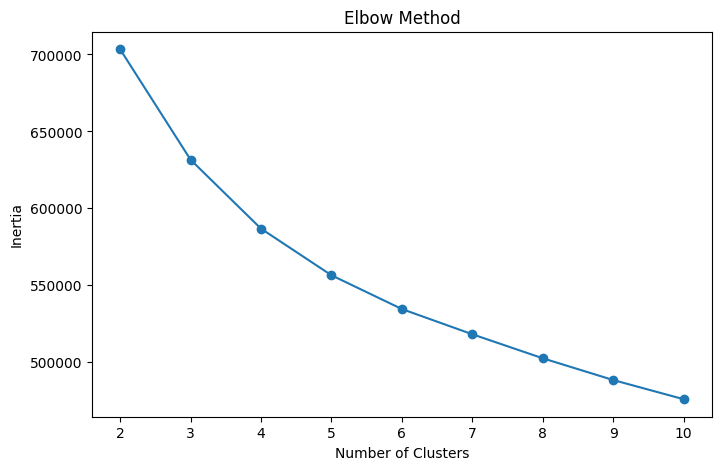

In [ ]:
from sklearn.cluster import KMeans

k_values = range(2, 11)

inertia_values = []

for k in k_values:

    kmeans = KMeans(
        n_clusters=k,
        random_state=42,
        n_init=10
    )

    kmeans.fit(
        X_clustering_scaled
    )

    inertia_values.append(
        kmeans.inertia_
    )

plt.figure(figsize=(8, 5))

plt.plot(
    k_values,
    inertia_values,
    marker="o"
)

plt.xlabel("Number of Clusters")
plt.ylabel("Inertia")
plt.title("Elbow Method")

plt.show()

### Apply K-Means Clustering

Applies K-Means using four clusters based on the Elbow Method and assigns each observation to its nearest cluster.

In [ ]:
optimal_k = 4

kmeans_final = KMeans(
    n_clusters=optimal_k,
    random_state=42,
    n_init=10
)

cluster_labels = kmeans_final.fit_predict(
    X_clustering_scaled
)

X_clustering["Cluster"] = cluster_labels

print(
    "Number of clusters:",
    X_clustering["Cluster"].nunique()
)

print(
    "Cluster sizes:"
)

display(
    X_clustering["Cluster"]
    .value_counts()
    .sort_index()
)

Number of clusters: 4
Cluster sizes:


,count
Cluster,
0,4897
1,7244
2,4963
3,7323


### 2D Cluster Visualization

This visualization shows the four K-Means clusters in a two-dimensional PCA space, highlighting the distribution and overlap between the identified groups.

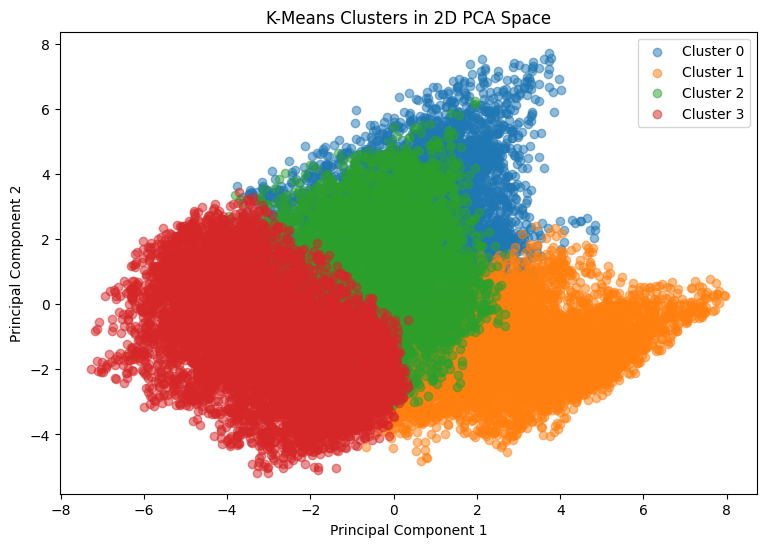

In [ ]:
from sklearn.decomposition import PCA

pca = PCA(n_components=2)

X_pca = pca.fit_transform(
    X_clustering_scaled
)

pca_clusters = pd.DataFrame({
    "PC1": X_pca[:, 0],
    "PC2": X_pca[:, 1],
    "Cluster": cluster_labels
})

plt.figure(figsize=(9, 6))

for cluster in sorted(
    pca_clusters["Cluster"].unique()
):

    cluster_data = pca_clusters[
        pca_clusters["Cluster"] == cluster
    ]

    plt.scatter(
        cluster_data["PC1"],
        cluster_data["PC2"],
        label=f"Cluster {cluster}",
        alpha=0.5
    )

plt.xlabel("Principal Component 1")
plt.ylabel("Principal Component 2")
plt.title("K-Means Clusters in 2D PCA Space")
plt.legend()

plt.show()

### Analyze Cluster Characteristics

Summarizes the average characteristics of each cluster to identify the main differences between the groups.

In [ ]:
cluster_profiles = (
    X_clustering
    .groupby("Cluster")
    .mean()
)

display(
    cluster_profiles
)

,generation fossil brown coal/lignite,generation fossil gas,generation fossil hard coal,generation fossil oil,generation hydro pumped storage consumption,generation hydro run-of-river and poundage,generation hydro water reservoir,generation nuclear,generation other renewable,forecast solar day ahead,price day ahead,temp,temp_min,temp_max,humidity,wind_speed,clouds_all,Hour,Month,Weekend,hour_sin,hour_cos,month_sin,month_cos,load_lag_1,load_lag_24,load_lag_48,load_lag_72,load_lag_168,load_rolling_mean_24,load_rolling_std_24,Season_Spring,Season_Summer,Season_Winter
Cluster,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,
0,735.228099,6886.163672,5962.865938,325.110884,115.189810,827.003982,3169.266081,6384.911681,84.594037,1209.561160,59.562481,285.020055,283.779754,286.573975,74.278877,2.369727,29.027216,14.303043,6.141719,0.203798,-0.167988,-0.193729,0.166147,0.655212,31770.590157,31246.085154,30728.514226,30736.356136,31005.262020,29571.113420,4164.669239,0.087809,0.000000,0.629569
1,577.638597,6290.998689,5158.472184,317.950373,174.394948,774.495168,2340.516151,6317.821507,82.118857,2566.058807,51.401622,298.528895,296.752497,300.388169,54.226297,2.601812,18.355156,14.195472,7.530784,0.270845,-0.239030,-0.342660,-0.519370,-0.507168,30834.811499,30607.876311,30580.658131,30585.152402,30605.800456,28906.850109,3708.524503,0.072060,0.653092,0.000138
2,155.417993,4193.975015,2625.480556,294.864699,442.814427,1287.995164,4058.086440,6372.193734,78.875479,1991.935120,38.024475,288.649086,287.372010,290.258417,64.041373,3.147568,30.190087,14.393310,4.024380,0.331654,-0.202009,-0.271793,0.699675,-0.193376,29215.963530,29829.987608,30094.730573,29986.039291,29921.419381,27770.223827,3607.357239,0.745114,0.027201,0.185775
3,411.247508,4509.466612,3893.613683,283.907893,1119.277482,811.580636,1438.621671,6309.802813,78.424826,218.362010,40.053673,286.882161,285.456185,288.547161,78.583566,1.895252,24.373728,4.992489,6.482999,0.323911,0.486246,0.652396,-0.021150,-0.035565,23730.697324,23910.075584,24101.841527,24147.588830,23972.873959,28101.506777,3540.311819,0.269562,0.240066,0.216714


### Cluster Demand Analysis

This step compares the actual electricity demand across the identified clusters to determine whether the clusters represent distinct demand patterns.

In [ ]:
cluster_demand = pd.DataFrame({
    "Cluster": cluster_labels,
    "Actual_Load": y_train.values
})

cluster_demand_summary = (
    cluster_demand
    .groupby("Cluster")["Actual_Load"]
    .agg(
        Count="count",
        Mean="mean",
        Median="median",
        Std="std",
        Minimum="min",
        Maximum="max"
    )
    .reset_index()
)

display(cluster_demand_summary)

,Cluster,Count,Mean,Median,Std,Minimum,Maximum
0,0,4897,31865.572698,32018.0,3443.825128,20909.0,41015.0
1,1,7244,30759.597046,30842.0,3471.551626,18616.0,40234.0
2,2,4963,29202.086540,29472.0,3406.708053,19351.0,40324.0
3,3,7323,23750.439847,23524.0,2310.862955,18041.0,37005.0


| Cluster | Profile | Interpretation |
|---|---|---|
| Cluster 0 | High electricity demand with relatively high fossil-fuel and hydro generation. This cluster represents periods when electricity demand is particularly high and the energy system operates with substantial conventional generation. | High-Demand Regime |
| Cluster 1 | High electricity demand associated with warmer temperatures and predominantly summer conditions. The cluster reflects periods of elevated demand under relatively warm weather conditions. | High-Demand Summer Regime |
| Cluster 2 | Moderate electricity demand with a stronger contribution from hydroelectric generation. This group represents periods where demand is lower than the high-demand clusters and hydro resources play a more important role. | Hydro-Intensive Regime |
| Cluster 3 | Low electricity demand, mainly associated with off-peak periods and relatively higher pumped-storage consumption. This cluster represents periods of lower system demand and different operating conditions from the high-demand groups. | Low-Demand Off-Peak Regime |

### Assign Cluster Labels

Based on the cluster demand profiles, each cluster was assigned a descriptive label reflecting its relative electricity demand level. These labels improve the interpretability of the clustering results and can be used in the subsequent Business Intelligence analysis.

In [ ]:
cluster_names = {
    0: "High Demand",
    1: "Relatively High Demand",
    2: "Medium Demand",
    3: "Low Demand"
}

combined_model.loc[
    X_clustering.index,
    "Cluster"
] = X_clustering["Cluster"]

combined_model["Cluster"] = (
    combined_model["Cluster"]
    .astype("Int64")
)

combined_model["Cluster_Name"] = (
    combined_model["Cluster"]
    .map(cluster_names)
)

display(
    combined_model[
        ["time", "Cluster", "Cluster_Name"]
    ]
    .dropna(subset=["Cluster"])
    .head()
)

,time,Cluster,Cluster_Name
0,2015-01-07 23:00:00+00:00,0,High Demand
1,2015-01-08 00:00:00+00:00,3,Low Demand
2,2015-01-08 01:00:00+00:00,3,Low Demand
3,2015-01-08 02:00:00+00:00,3,Low Demand
4,2015-01-08 03:00:00+00:00,3,Low Demand


### Merge Cluster Information into the Main Dataset

The generated cluster labels and descriptive names are added to the main dataset so that each observation is associated with its corresponding electricity demand cluster. This enriched dataset will be used for the subsequent Business Intelligence analysis and Tableau dashboards.

In [ ]:
combined_model.loc[
    X_clustering.index,
    "Cluster"
] = X_clustering["Cluster"]

combined_model.loc[
    X_clustering.index,
    "Cluster_Name"
] = X_clustering["Cluster"].map(
    cluster_names
)

display(
    combined_model[
        ["time", "Cluster", "Cluster_Name"]
    ].dropna().head()
)

,time,Cluster,Cluster_Name
0,2015-01-07 23:00:00+00:00,0,High Demand
1,2015-01-08 00:00:00+00:00,3,Low Demand
2,2015-01-08 01:00:00+00:00,3,Low Demand
3,2015-01-08 02:00:00+00:00,3,Low Demand
4,2015-01-08 03:00:00+00:00,3,Low Demand


### Clustering Analysis Results

K-Means clustering was applied to 24,427 observations using 34 standardized features. The Elbow Method indicated that four clusters provide a suitable balance between within-cluster variation and model complexity. The resulting clusters contained 4,897, 7,244, 4,963, and 7,323 observations, respectively.

The clusters showed clear differences in electricity-demand levels. Cluster 0 represented the highest-demand group, with a mean actual load of 31,866 MW, while Cluster 3 represented the lowest-demand group, with a mean of 23,750 MW. Clusters 1 and 2 represented intermediate demand levels, with mean loads of 30,760 MW and 29,202 MW, respectively.

The cluster characteristics also differed across generation, weather, and temporal variables. Cluster 0 was associated with higher fossil-gas generation and relatively high demand, whereas Cluster 3 showed lower demand and higher pumped-storage consumption. The PCA visualization showed a clear separation between the four groups, supporting the presence of distinct observation patterns.

Overall, the clustering results indicate that the electricity dataset contains distinct demand and operating regimes, which can provide useful business insights for understanding different electricity-consumption conditions and supporting subsequent analysis.

## Export Final Dataset to Excel

The final enriched dataset is exported to Excel for use in Tableau. It includes the engineered features, selected predictors, cluster assignments, and descriptive cluster labels.

In [ ]:
output_path = "final_electricity_demand_tableau.xlsx"

tableau_data = combined_model.copy()

for column in tableau_data.select_dtypes(
    include=["datetime", "datetimetz"]
).columns:

    tableau_data[column] = (
        tableau_data[column]
        .dt.tz_localize(None)
    )

tableau_data.to_excel(
    output_path,
    sheet_name="Final Dataset",
    index=False
)

print("File saved successfully:", output_path)

File saved successfully: final_electricity_demand_tableau.xlsx


In [ ]:
from google.colab import files

files.download(output_path)

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

# Tools, Research, and Selection Effort

## Python

Python was used as the main programming language for data preprocessing, feature engineering, statistical analysis, predictive modeling, hyperparameter tuning, model evaluation, and clustering. Key libraries included Pandas, NumPy, Matplotlib, Scikit-learn, Statsmodels, and XGBoost. Python was selected because of its broad support for data analysis, statistical modeling, and machine learning.

## Google Colab

Google Colab served as the primary development environment for implementing the data preprocessing, statistical analysis, regression models, XGBoost modeling, and clustering procedures. It provided a convenient cloud-based environment for notebook development and model execution.

## Microsoft Excel

Microsoft Excel was used for initial data inspection, verification, basic organization, and manual review of the datasets before the advanced analytical stages. It was also used to inspect the data structure, variable names, and preliminary values.

## Tableau

Tableau was selected as the main platform for developing the final interactive Business Intelligence dashboards. It was used to present analytical results, visualize electricity demand patterns, compare model performance, and communicate the main findings through interactive visualizations.

## Integration

The selected tools created an integrated analytical workflow covering data inspection, preprocessing, feature engineering, statistical analysis, predictive modeling, clustering, model evaluation, and interactive Business Intelligence visualization. This integration supported the development of a data-driven electricity demand analysis and forecasting system.

# Project Deployment Effort & Use Case

The project was deployed as a Business Intelligence analytical solution rather than as a standalone production forecasting API. Python and Google Colab were used for data preparation, feature engineering, statistical analysis, machine learning, and clustering, while the final enriched dataset was exported to Excel for integration with Tableau.

## Deployment Effort

The overall deployment effort can be considered moderate, as the project required integration of several analytical stages into one workflow:

Data preprocessing and feature engineering.
Time-series and statistical analysis.
Predictive model development and evaluation.
Hyperparameter tuning and final model selection.
K-Means clustering and cluster interpretation.
Integration of cluster labels into the main dataset.
Development of two interactive Tableau dashboards.

The final Tableau dataset contains the engineered variables together with the cluster assignments and descriptive cluster labels, allowing the analytical results to be transferred into an interactive BI environment.

## Business Use Case

The solution can support electricity system planning and operational analysis by combining demand patterns, demand regimes, and energy-generation information.

The first Tableau dashboard allows users to explore electricity demand across time and interactively filter the observations by cluster. This can help analysts distinguish between high-, medium-, and low-demand operating regimes and examine their temporal behavior.

The second dashboard focuses on the energy-generation mix. Users can select an individual energy source and examine its generation trend, monthly behavior, and relationship with renewable and fossil generation. This provides a practical basis for monitoring changes in the energy mix and identifying sources that may become more or less important over time.

In practice, the solution could therefore be used by energy planners, electricity-market analysts, and system operators to monitor demand regimes, compare energy sources, and support data-driven planning decisions. The current implementation should be considered a BI decision-support prototype, rather than a fully automated real-time forecasting system.

# Results

The analysis produced two complementary outcomes: a supervised electricity demand forecasting model and an unsupervised clustering analysis designed to identify distinct electricity demand profiles. These results were subsequently integrated into an interactive Tableau dashboard to support business-oriented exploration of electricity demand and energy generation patterns.

### Electricity Demand Forecasting Results

The XGBoost model demonstrated strong predictive performance on the electricity demand forecasting task. Hyperparameter tuning was performed using the validation dataset, with the model configurations compared according to MAE, RMSE, MAPE, and R². The best-performing configuration used 700 estimators, a learning rate of 0.03, a maximum tree depth of 8, a minimum child weight of 1, a subsample ratio of 0.8, and a column sampling ratio of 0.8.

The selected model achieved a validation MAE of 373.97 and a validation RMSE of 546.24, with an R² of 0.9866 and a MAPE of 1.32%. These results indicate that the model was able to explain most of the variation in electricity demand while maintaining relatively low prediction errors.

The comparison between training and validation performance showed a training RMSE of 151.99 compared with a validation RMSE of 546.24. The corresponding training and validation R² values were 0.9989 and 0.9866, respectively. Although the training performance was stronger than the validation performance, the validation results remained high, indicating that the model retained strong predictive capability on observations that were not used during model fitting.

The learning curve analysis further showed that increasing the number of estimators consistently improved validation performance within the evaluated range. Validation RMSE decreased from approximately 695.81 at 100 estimators to 546.24 at 700 estimators, while validation R² increased from approximately 0.9783 to 0.9866. This indicates that the selected 700-tree configuration provided the strongest validation performance among the tested values and that the model had not reached a clear deterioration in validation performance within the investigated range.

The final evaluation on the independent test dataset produced a MAE of 397.26, an RMSE of 560.96, a MAPE of 1.42%, and an R² of 0.9850. The relatively small difference between the validation and test performance provides evidence that the selected XGBoost model generalized well to unseen observations. The test results also confirm that the forecasting model maintained high explanatory power outside the training and validation datasets.

### Feature Importance Results

The feature importance analysis identified previous electricity demand as the dominant predictor of the current demand level. The most important feature was load_lag_1, with an importance of approximately 0.496. This indicates that the electricity demand observed in the previous time period provides substantial information for predicting the current demand.

The second most influential predictor was generation hydro pumped storage consumption, followed by Hour and hour_cos. The importance of these variables indicates that both energy-system conditions and temporal patterns contribute to electricity demand prediction.

Other influential predictors included the 24-hour rolling mean of demand, load_lag_24, Weekend, hour_sin, and several electricity generation variables. The presence of lagged demand and rolling statistics among the most important predictors supports the importance of temporal dependence in electricity consumption patterns.

Overall, the feature importance results show that electricity demand is strongly associated with its recent historical behavior, while time-of-day characteristics, weekly patterns, and energy-generation conditions provide additional predictive information.

### Clustering Results

The unsupervised analysis was performed using K-Means clustering after standardizing the selected numerical features. The clustering dataset contained 34 features and 24,427 observations. Standardization was applied to ensure that variables measured on different scales did not disproportionately influence the distance calculations used by K-Means.

The Elbow Method was used to investigate the appropriate number of clusters. The inertia decreased substantially as the number of clusters increased, with the reduction becoming progressively smaller after the initial increases in cluster count. Based on the resulting structure and the objective of obtaining interpretable demand groups, four clusters were selected for the final K-Means analysis.

The resulting clusters showed clear differences in electricity demand characteristics. The cluster profiles were interpreted according to their average, median, minimum, and maximum actual demand values, together with their associated energy-generation, weather, temporal, and lagged-demand characteristics.

The high-demand cluster was characterized by the highest average electricity demand and the highest observed demand level among the identified groups. Its demand profile indicates periods of relatively strong electricity consumption and therefore represents conditions associated with high system demand.

The medium-demand cluster represented an intermediate demand profile, with electricity consumption levels positioned between the higher- and lower-demand groups. This cluster provides a distinct operational profile rather than simply representing an extension of the high-demand group.

The low-demand cluster contained observations associated with substantially lower electricity demand. Its profile was also associated with different temporal and energy-generation characteristics, indicating that low-demand periods are influenced by a combination of demand behavior and system conditions.

The remaining cluster represented a relatively high or transitional demand profile and demonstrated characteristics that distinguished it from the other groups. The clustering results therefore provide a segmentation of electricity demand conditions rather than a simple division based only on the magnitude of actual load.

The PCA visualization of the clusters showed a visible separation between the identified groups in the reduced feature space. Although some overlap remained between neighboring clusters, the overall distribution demonstrated that the K-Means algorithm captured meaningful structural differences within the electricity demand data.

### Cluster Demand Analysis

The demand statistics confirmed that the clusters differ substantially in their electricity consumption levels. The highest-demand group had an average demand of approximately 31,866, while the medium-demand groups had lower average levels and the low-demand group had an average demand of approximately 23,750. The maximum observed demand also varied across the clusters, with the highest cluster reaching approximately 41,015.

These differences demonstrate that the clustering process successfully identified groups with distinct demand regimes. The clusters can therefore be used as an additional analytical dimension for understanding electricity demand behavior and for segmenting observations into operationally meaningful demand conditions.

The cluster labels were merged back into the main dataset together with descriptive cluster names. This integration enables each observation to be associated with both its original electricity and environmental characteristics and its corresponding demand profile. The resulting enriched dataset provides the basis for the interactive Tableau analysis.

### Energy Generation Analysis

The energy-generation analysis extended the project beyond electricity demand by examining the contribution and temporal behavior of different energy sources. The dataset contains generation variables representing fossil, nuclear, hydroelectric, solar, and other renewable sources.

The analysis showed that energy sources do not contribute equally to total generation. Different generation technologies exhibit different levels and temporal patterns, making source-level analysis important for understanding the composition of the electricity system.

The interactive energy dashboard was therefore designed to allow users to select an individual energy source and examine its generation trend over time and across months. This approach makes it possible to compare energy sources while avoiding the loss of information that can occur when all generation technologies are aggregated into a single measure.

The comparison between renewable and fossil generation also provides a broader view of the evolution of the electricity generation mix over the study period. Examining these trends together helps identify changes in the relative contribution of different energy categories and provides an exploratory basis for discussing the future direction of the energy mix.

### Overall Findings

The combined results demonstrate that electricity demand contains strong temporal and historical patterns that can be effectively modeled using machine-learning techniques. XGBoost achieved high predictive performance and maintained strong performance on the independent test dataset, indicating good generalization to unseen observations.

At the same time, the clustering analysis revealed that electricity demand is not homogeneous across time. The observations can be segmented into distinct demand profiles with different levels of electricity consumption and different associated system characteristics.

The integration of the cluster labels into the main dataset allows these demand profiles to be explored together with temporal variables, energy-generation variables, and other explanatory characteristics. This creates a more comprehensive analytical framework in which forecasting and segmentation provide complementary perspectives on the electricity system.

Finally, the Tableau dashboards transform these analytical results into an interactive decision-support environment. The demand dashboard enables users to explore overall demand behavior and dynamically filter observations by cluster, while the energy dashboard focuses on the generation mix and allows individual energy sources to be selected and compared through their trends. Together, the dashboards provide a concise visual representation of the main findings without directly exposing the machine-learning model outputs as dashboard components.

# References

Rubio-León, J., Rubio-Cienfuegos, J., Vidal-Silva, C., Cárdenas-Cobo, J., & Duarte, V. (2023). Applying fuzzy time series for developing forecasting electricity demand models. Mathematics, 11(17), 3667. https://doi.org/10.3390/math11173667

Valor, E., Meneu, V., & Caselles, V. (2001). Daily air temperature and electricity load in Spain. Journal of Applied Meteorology, 40(8), 1413–1421. https://doi.org/10.1175/1520-0450(2001)040<1413:DATAEL>2.0.CO;2

Hoerl, A. E., & Kennard, R. W. (1970). Ridge regression: Biased estimation for nonorthogonal problems. Technometrics, 12(1), 55–67. https://doi.org/10.1080/00401706.1970.10488634

Chen, T., & Guestrin, C. (2016). XGBoost: A scalable tree boosting system. Proceedings of the 22nd ACM SIGKDD International Conference on Knowledge Discovery and Data Mining, 785–794. https://doi.org/10.1145/2939672.2939785

MacQueen, J. (1967). Some methods for classification and analysis of multivariate observations. Proceedings of the Fifth Berkeley Symposium on Mathematical Statistics and Probability, 1, 281–297. University of California Press.